# OCR for Smart School Correction

This notebook builds an end-to-end optical character recognition (OCR) pipeline for the school correction project. We start from raw IDX image files, inspect the dataset, prepare the data, train a baseline model and a convolutional neural network, and finish with evaluation, error analysis, and an interactive drawing demo.

The notebook is organized so each section answers one question:
- What does the data look like?
- How do we preprocess it?
- Which model performs better?
- Where does the classifier still fail?

Use the outputs as a technical appendix for the final project report.


## Dataset Snapshot

Before training, we verify the dataset format and class structure.

- Images are grayscale `28 x 28` handwritten characters.
- There are `62` classes: digits, uppercase letters, and lowercase letters.
- The raw files are stored in IDX format, so we read them directly from the binary files.
- The notebook applies the same rotation and transpose convention as the project helper script so images appear in the correct orientation.
- We keep the original train/test split and later carve out a validation subset from the training data.

This section gives a compact technical overview of the data that drives the rest of the pipeline.


## 1. Environment and Imports

We import the numerical, plotting, and machine learning libraries needed for data loading, model training, and evaluation. This cell also sets up the display utilities used later in the notebook.


In [1]:
from pathlib import Path
import struct
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(42)

try:
    import tensorflow as tf
    from tensorflow import keras
except ImportError as exc:
    raise ImportError(
        'TensorFlow is required for the CNN section. Run this notebook on Kaggle or install tensorflow.'
    ) from exc

tf.random.set_seed(42)
print('TensorFlow version:', tf.__version__)
print('GPU available:', bool(tf.config.list_physical_devices('GPU')))


I0000 00:00:1779200772.850394 1483390 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779200773.340105 1483390 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779200775.322427 1483390 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0
GPU available: False


E0000 00:00:1779200775.740500 1483390 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Locate the Dataset

The notebook is designed to run in multiple environments, including the local project folder and Kaggle. The following helper scans a small list of known locations and selects the first path that exists.


In [2]:
# Locate the dataset whether the notebook is run from Project2026/ or the repo root.
DATA_DIR_CANDIDATES = [
    Path('data/project_2026_dataset/student_dataset/image_data'),
    Path('Project2026/data/project_2026_dataset/student_dataset/image_data'),
    Path('../input/project_2026_dataset/student_dataset/image_data'),
    Path('/kaggle/input/project_2026_dataset/student_dataset/image_data'),
    Path('/kaggle/input/project-2026-dataset/student_dataset/image_data'),
]

def find_data_dir():
    for candidate in DATA_DIR_CANDIDATES:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find the OCR dataset directory.')


DATA_DIR = find_data_dir()
MAPPING_PATH = DATA_DIR / 'mapping.txt'
TRAIN_IMAGES_PATH = DATA_DIR / 'train-images-idx3-ubyte'
TRAIN_LABELS_PATH = DATA_DIR / 'train-labels-idx1-ubyte'
TEST_IMAGES_PATH = DATA_DIR / 'test-images-idx3-ubyte'
TEST_LABELS_PATH = DATA_DIR / 'test-labels-idx1-ubyte'

def load_mapping(path):
    mapping = {}
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            idx_str, ascii_str = line.split()
            mapping[int(idx_str)] = chr(int(ascii_str))
    return mapping


def load_idx_images(path):
    with path.open('rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        if magic != 2051:
            raise ValueError(f'Unexpected image magic number: {magic}')
        images = np.frombuffer(f.read(), dtype=np.uint8)
    images = images.reshape(num, rows, cols)
    # Match the orientation used by the helper script shipped with the project.
    return np.transpose(images, (0, 2, 1)).copy()


def load_idx_labels(path):
    with path.open('rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        if magic != 2049:
            raise ValueError(f'Unexpected label magic number: {magic}')
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels.astype(np.int64)


mapping = load_mapping(MAPPING_PATH)
label_names = [mapping[i] for i in range(len(mapping))]
num_classes = len(label_names)

print('Data directory:', DATA_DIR)
print('Classes:', num_classes)
print('First 15 labels:', label_names[:15])


Data directory: data/project_2026_dataset/student_dataset/image_data
Classes: 62
First 15 labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E']


## 3. Load and Summarize the Data

Here we load the IDX image and label files, then compute a compact summary of the train and test splits. This gives an early check on sample counts, image shapes, and label balance.

we then split the dataset between train and test components.


In [3]:
x_train_raw = load_idx_images(TRAIN_IMAGES_PATH)
y_train_raw = load_idx_labels(TRAIN_LABELS_PATH)
x_test_raw = load_idx_images(TEST_IMAGES_PATH)
y_test_raw = load_idx_labels(TEST_LABELS_PATH)

train_counts = np.bincount(y_train_raw, minlength=num_classes)
test_counts = np.bincount(y_test_raw, minlength=num_classes)

summary = pd.DataFrame({
    'split': ['train', 'test'],
    'n_samples': [len(y_train_raw), len(y_test_raw)],
    'image_shape': [str(x_train_raw.shape[1:]), str(x_test_raw.shape[1:])],
    'n_classes': [len(np.unique(y_train_raw)), len(np.unique(y_test_raw))],
    'pixel_min': [int(x_train_raw.min()), int(x_test_raw.min())],
    'pixel_max': [int(x_train_raw.max()), int(x_test_raw.max())],
    'pixel_mean': [float(x_train_raw.mean()), float(x_test_raw.mean())],
    'pixel_std': [float(x_train_raw.std()), float(x_test_raw.std())],
})

display(summary)
print('Any missing labels in train?', np.isnan(y_train_raw).any())
print('Any missing labels in test?', np.isnan(y_test_raw).any())
top_train = train_counts.argsort()[::-1][:10]
print('Top 10 train classes:', [(label_names[idx], int(train_counts[idx])) for idx in top_train])


,split,n_samples,image_shape,n_classes,pixel_min,pixel_max,pixel_mean,pixel_std
0,train,697932,"(28, 28)",62,0,255,44.266017,84.571172
1,test,116323,"(28, 28)",62,0,255,44.271084,84.571629


Any missing labels in train? False
Any missing labels in test? False
Top 10 train classes: [('1', 38374), ('7', 35754), ('3', 35143), ('0', 34585), ('6', 34232), ('2', 34203), ('8', 33946), ('9', 33847), ('4', 33535), ('5', 31416)]


## 4. Visual Inspection

A few sample images help confirm that preprocessing is correct and that labels match the handwritten characters. Visual checks are especially useful for OCR because they expose orientation issues, noise, and ambiguous classes.


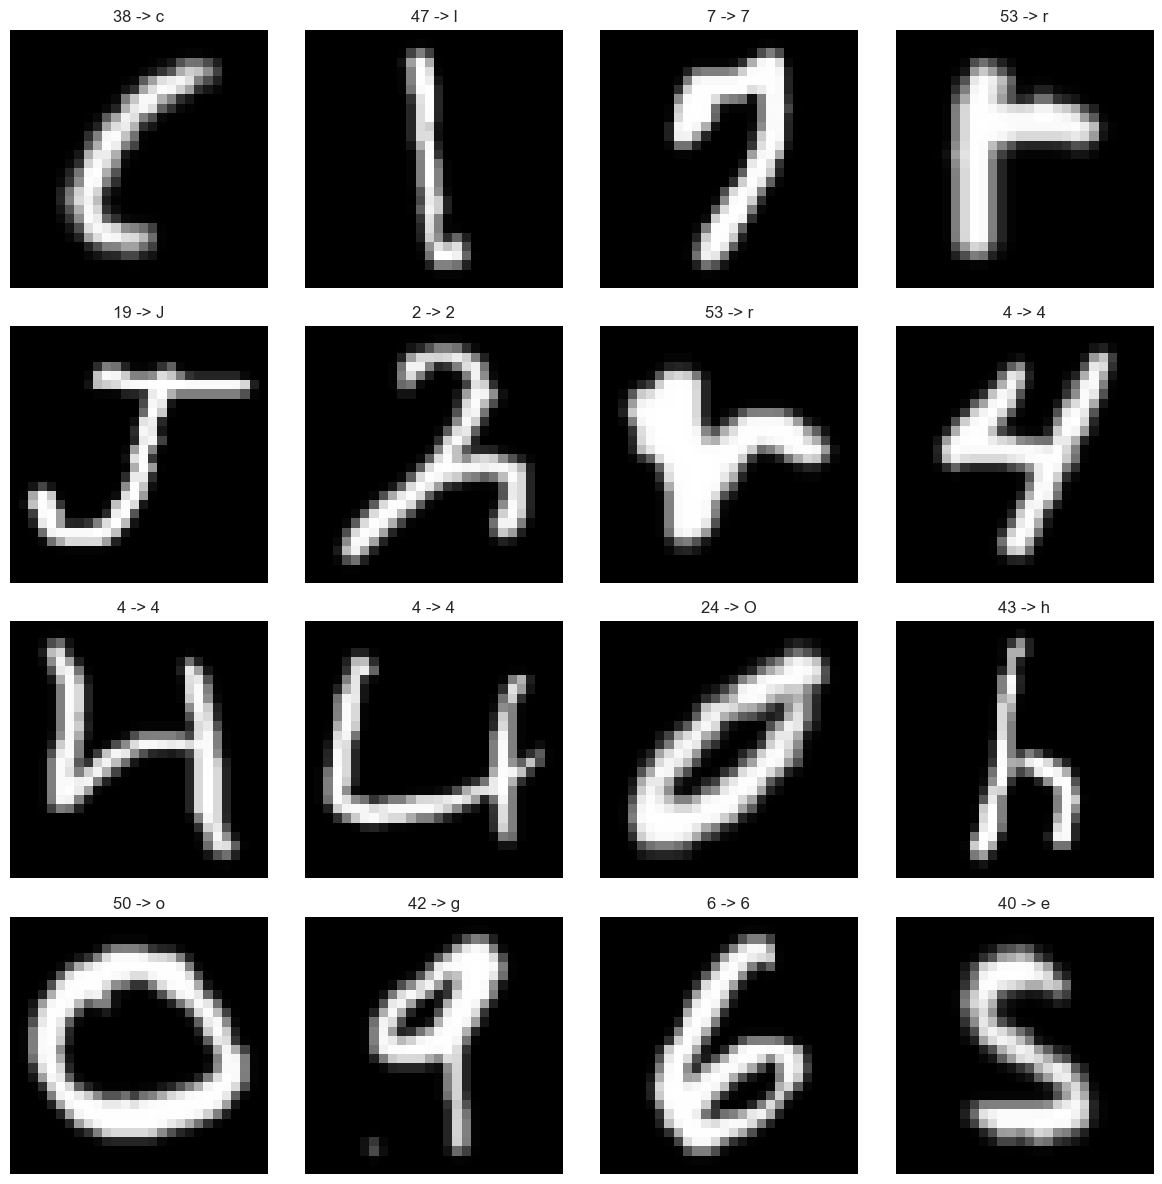

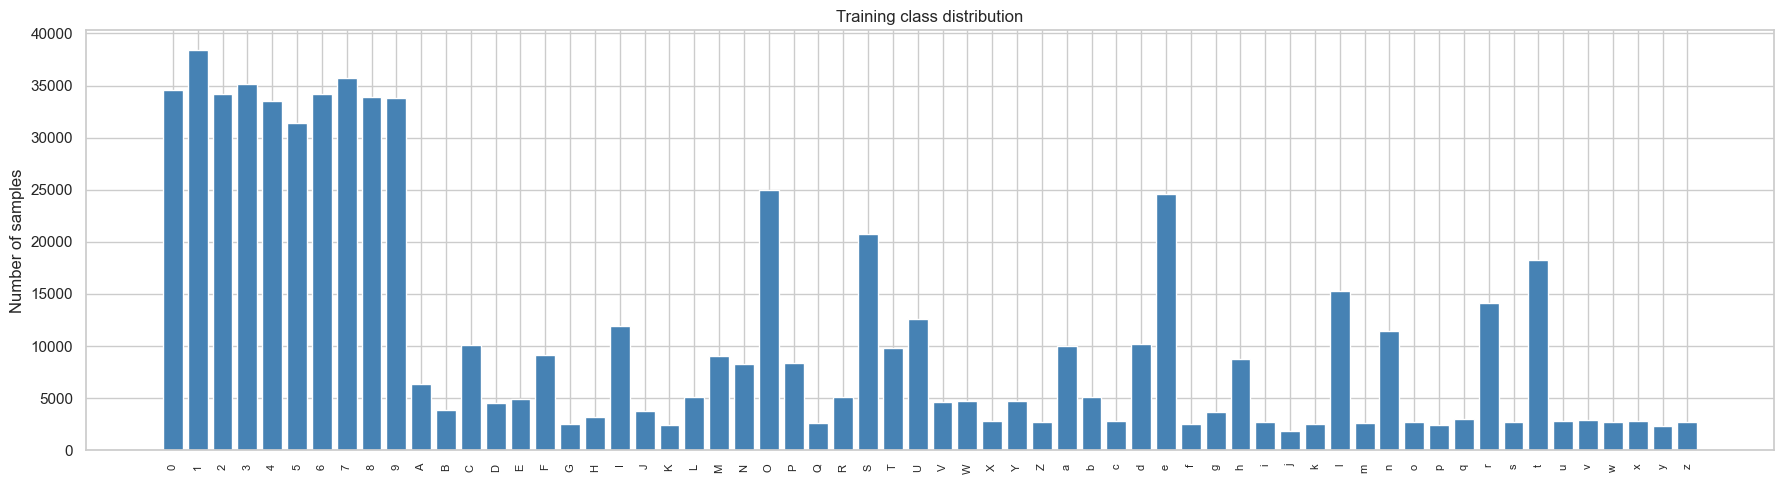

In [4]:
def show_samples(images, labels, names, n=16, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(labels), size=n, replace=False)
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).reshape(-1)
    for ax, sample_idx in zip(axes, idx):
        ax.imshow(images[sample_idx], cmap='gray')
        ax.set_title(f"{labels[sample_idx]} -> {names[int(labels[sample_idx])]}")
        ax.axis('off')
    for ax in axes[len(idx):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


show_samples(x_train_raw, y_train_raw, label_names, n=16)

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(np.arange(num_classes), train_counts, color='steelblue')
ax.set_xticks(np.arange(num_classes))
ax.set_xticklabels(label_names, rotation=90, fontsize=8)
ax.set_title('Training class distribution')
ax.set_ylabel('Number of samples')
plt.tight_layout()
plt.show()


## 5. Preprocessing and Sampling Strategy

The full training set is large, so the notebook supports optional subsampling for faster iteration. We also reserve a validation split from the training portion so we can compare models without touching the held-out test set.

Key steps in this section:
- normalize and reshape the images
- create train, validation, and test subsets
- keep class proportions stable through stratified sampling


In [5]:
# Set these to None if you want to run on the full splits.
# The defaults keep the notebook practical for local iteration while still using a large sample.
TRAIN_LIMIT = 120_000
TEST_LIMIT = 20_000
VALIDATION_SIZE = 0.15

def sample_indices(y, limit, random_state=42):
    idx = np.arange(len(y))
    if limit is None or limit >= len(idx):
        return idx
    sampled, _ = train_test_split(idx, train_size=limit, stratify=y, random_state=random_state)
    return np.sort(sampled)


train_idx = sample_indices(y_train_raw, TRAIN_LIMIT)
test_idx = sample_indices(y_test_raw, TEST_LIMIT)

x_train_subset = x_train_raw[train_idx].astype('float32') / 255.0
y_train_subset = y_train_raw[train_idx]
x_test_subset = x_test_raw[test_idx].astype('float32') / 255.0
y_test_subset = y_test_raw[test_idx]


def build_foreground_mask(images, threshold=0.02, dilation=3):
    images = np.asarray(images, dtype=np.float32)
    single_image = images.ndim == 2
    if single_image:
        images = images[None, ...]
    binary = (images > threshold).astype(np.float32)[..., np.newaxis]
    dilated = tf.nn.max_pool2d(binary, ksize=dilation, strides=1, padding='SAME')
    softened = tf.nn.avg_pool2d(dilated, ksize=3, strides=1, padding='SAME').numpy()[..., 0]
    mask = np.maximum(softened, images)
    mask = np.clip(mask, 0.0, 1.0)
    return mask[0] if single_image else mask


def prepare_cnn_input(images):
    images = np.asarray(images, dtype=np.float32)
    if images.ndim == 2:
        masks = build_foreground_mask(images)
        return np.stack([images, masks], axis=-1)

    if images.ndim != 3:
        raise ValueError(f'Expected a 2D image or a 3D batch, got shape {images.shape}')

    masks = build_foreground_mask(images)
    return np.stack([images, masks], axis=-1)


x_train, x_val, y_train, y_val = train_test_split(
    x_train_subset,
    y_train_subset,
    test_size=VALIDATION_SIZE,
    stratify=y_train_subset,
    random_state=42,
)

x_train_cnn = prepare_cnn_input(x_train)
x_val_cnn = prepare_cnn_input(x_val)
x_test_cnn = prepare_cnn_input(x_test_subset)

print('Train:', x_train.shape, y_train.shape)
print('Validation:', x_val.shape, y_val.shape)
print('Test:', x_test_subset.shape, y_test_subset.shape)
print('CNN input shape:', x_train_cnn.shape)
print('Pixel range after normalization:', float(x_train.min()), float(x_train.max()))


Train: (102000, 28, 28) (102000,)
Validation: (18000, 28, 28) (18000,)
Test: (20000, 28, 28) (20000,)
CNN input shape: (102000, 28, 28, 2)
Pixel range after normalization: 0.0 1.0


## 6. Baseline Model

We start with a lightweight linear classifier on flattened pixels. This baseline is intentionally simple: it trains quickly and gives us a reference point before moving to the convolutional model.

If the CNN does not improve meaningfully over this baseline, that is an important signal that the model or preprocessing pipeline needs attention.


,split,accuracy,precision_macro,recall_macro,f1_macro
0,validation,0.506889,0.448364,0.432500,0.382893
1,test,0.504600,0.441273,0.426856,0.374214


              precision    recall  f1-score   support

           0       0.63      0.53      0.57       993
           1       0.59      0.49      0.54      1088
           2       0.89      0.55      0.68      1009
           3       0.81      0.86      0.83      1026
           4       0.91      0.37      0.53       966
           5       0.74      0.54      0.62       892
           6       0.82      0.80      0.81       981
           7       0.95      0.81      0.88      1056
           8       0.89      0.48      0.63       969
           9       0.86      0.68      0.76       978
           A       0.36      0.54      0.43       183
           B       0.24      0.37      0.29       111
           C       0.47      0.44      0.45       299
           D       0.15      0.65      0.25       134
           E       0.82      0.25      0.38       146
           F       0.48      0.10      0.17       248
           G       0.23      0.44      0.30        77
           H       0.48    

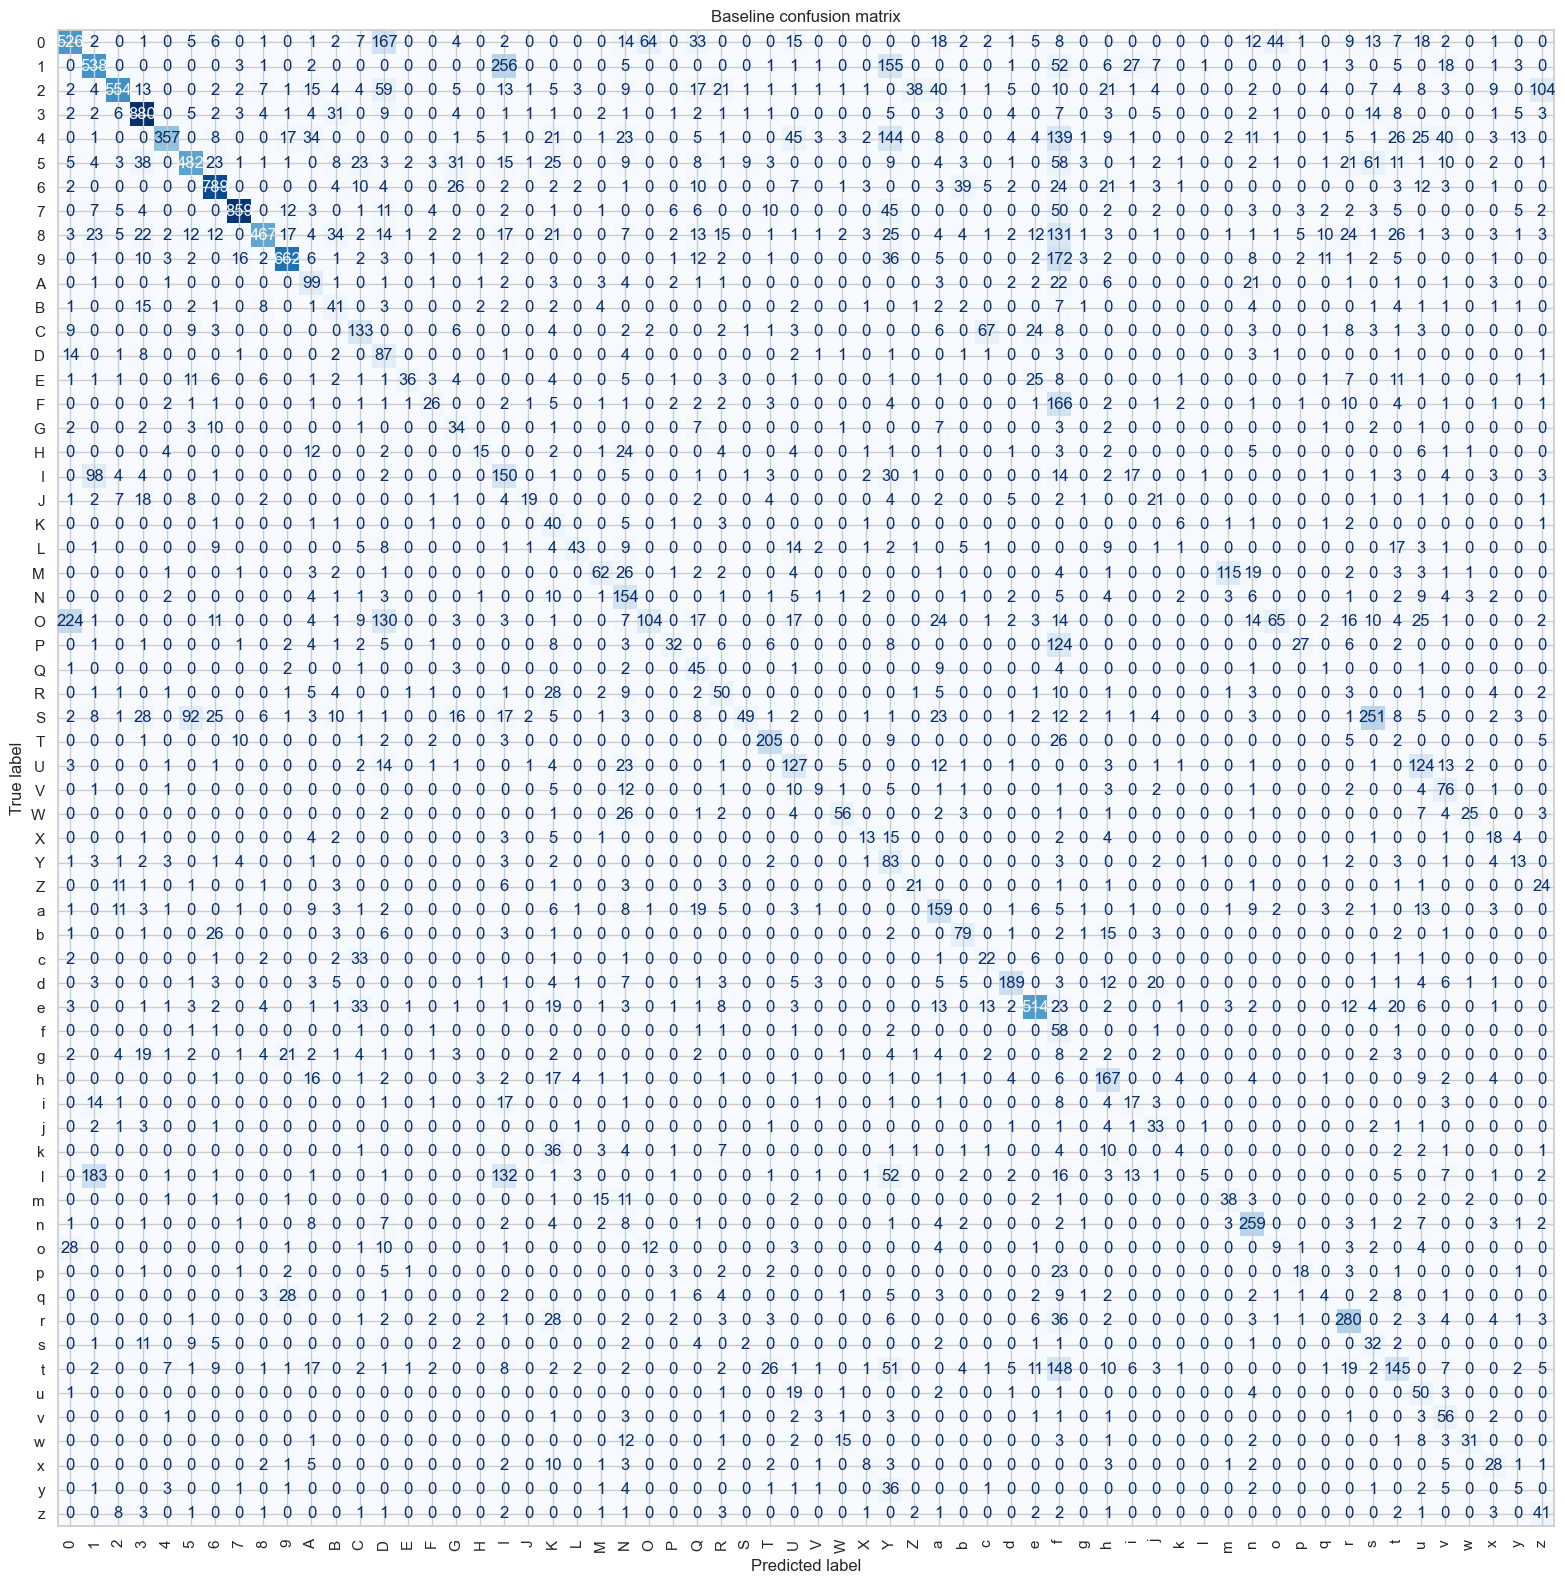

In [6]:
# Baseline: simple linear classifier on flattened pixels.
# This gives a fast reference point before the CNN.
x_train_flat = x_train.reshape(len(x_train), -1)
x_val_flat = x_val.reshape(len(x_val), -1)
x_test_flat = x_test_subset.reshape(len(x_test_subset), -1)

baseline = SGDClassifier(
    loss='log_loss',
    alpha=1e-5,
    max_iter=20,
    tol=1e-3,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
)
baseline.fit(x_train_flat, y_train)

val_baseline_pred = baseline.predict(x_val_flat)
test_baseline_pred = baseline.predict(x_test_flat)

baseline_metrics = {
    'split': ['validation', 'test'],
    'accuracy': [accuracy_score(y_val, val_baseline_pred), accuracy_score(y_test_subset, test_baseline_pred)],
    'precision_macro': [precision_score(y_val, val_baseline_pred, average='macro', zero_division=0), precision_score(y_test_subset, test_baseline_pred, average='macro', zero_division=0)],
    'recall_macro': [recall_score(y_val, val_baseline_pred, average='macro', zero_division=0), recall_score(y_test_subset, test_baseline_pred, average='macro', zero_division=0)],
    'f1_macro': [f1_score(y_val, val_baseline_pred, average='macro', zero_division=0), f1_score(y_test_subset, test_baseline_pred, average='macro', zero_division=0)],
}

display(pd.DataFrame(baseline_metrics))
print(classification_report(y_test_subset, test_baseline_pred, target_names=label_names, zero_division=0))

cm_baseline = confusion_matrix(y_test_subset, test_baseline_pred, labels=np.arange(num_classes))
fig, ax = plt.subplots(figsize=(18, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=label_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='.0f')
plt.xticks(rotation=90)
plt.title('Baseline confusion matrix')
plt.tight_layout()
plt.show()


## 7. Convolutional Neural Network

The main model is a CNN, which can learn spatial patterns such as strokes, curves, and intersections directly from the image grid. Compared with the linear baseline, it is better suited to handwritten character recognition.

This version adds light augmentation, a deeper convolutional stack, spatial dropout, and a two-channel input: the grayscale image plus a soft foreground mask that keeps the character and its gray contours. It still uses the same stability ideas as the failure-prediction project: early stopping and learning-rate reduction.


In [7]:
class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {int(cls): float(weight)
                     for cls, weight in zip(np.unique(y_train), class_weights)}

keras.backend.clear_session()

data_augmentation = keras.Sequential([
    keras.layers.RandomTranslation(0.08, 0.08, fill_mode='nearest'),
    keras.layers.RandomRotation(0.06, fill_mode='nearest'),
    # 0.10 → 0.05, trop agressif sur 28x28
    keras.layers.RandomZoom(0.05, 0.05, fill_mode='nearest'),
], name='data_augmentation')

cnn = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 2)),
    data_augmentation,

    # Bloc 1 — features simples, 32 filtres suffisent à ce stade
    keras.layers.Conv2D(32, 3, padding='same', use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.SpatialDropout2D(0.10),

    # Bloc 2 — 14x14, on monte à 64
    keras.layers.Conv2D(64, 3, padding='same', use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    # double bloc justifié ici
    keras.layers.Conv2D(64, 3, padding='same', use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.SpatialDropout2D(0.20),

    # Bloc 3 — 7x7, features complexes
    keras.layers.Conv2D(128, 3, padding='same', use_bias=False),
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),
    keras.layers.MaxPooling2D(),

    # Tête de classification
    # produit 128 valeurs, pas besoin de Dense cachée
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(num_classes, activation='softmax'),
])

cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5),
]

history = cnn.fit(
    x_train_cnn,
    y_train,
    validation_data=(x_val_cnn, y_val),
    epochs=50,                # les callbacks gèrent l'arrêt
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/50


W0000 00:00:1779200857.493535 1483390 cpu_allocator_impl.cc:82] Allocation of 639744000 exceeds 10% of free system memory.


399/399 ━━━━━━━━━━━━━━━━━━━━ 128s 314ms/step - accuracy: 0.1478 - loss: 3.4877 - val_accuracy: 0.4079 - val_loss: 2.7211 - learning_rate: 5.0000e-04
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 122s 306ms/step - accuracy: 0.3953 - loss: 2.2114 - val_accuracy: 0.7031 - val_loss: 1.1684 - learning_rate: 5.0000e-04
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 123s 308ms/step - accuracy: 0.5087 - loss: 1.6890 - val_accuracy: 0.7362 - val_loss: 0.8928 - learning_rate: 5.0000e-04
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 126s 315ms/step - accuracy: 0.5613 - loss: 1.4390 - val_accuracy: 0.7443 - val_loss: 0.8056 - learning_rate: 5.0000e-04
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 124s 311ms/step - accuracy: 0.5978 - loss: 1.2844 - val_accuracy: 0.7579 - val_loss: 0.7163 - learning_rate: 5.0000e-04
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 124s 309ms/step - accuracy: 0.6201 - loss: 1.1855 - val_accuracy: 0.7538 - val_loss: 0.7172 - learning_rate: 5.0000e-04
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 118s 295ms/

## 8. Training Curves

After training, we inspect the loss and accuracy curves to understand convergence behavior. A healthy fit should show training and validation metrics moving in the same direction without a large gap.


,accuracy,loss,val_accuracy,val_loss,learning_rate
37,0.739608,0.732440,0.795222,0.544311,0.000063
38,0.743255,0.727005,0.796833,0.542336,0.000031
39,0.743539,0.727099,0.796000,0.546373,0.000031
40,0.744539,0.730095,0.797944,0.543438,0.000031
41,0.746716,0.726052,0.798778,0.542090,0.000016


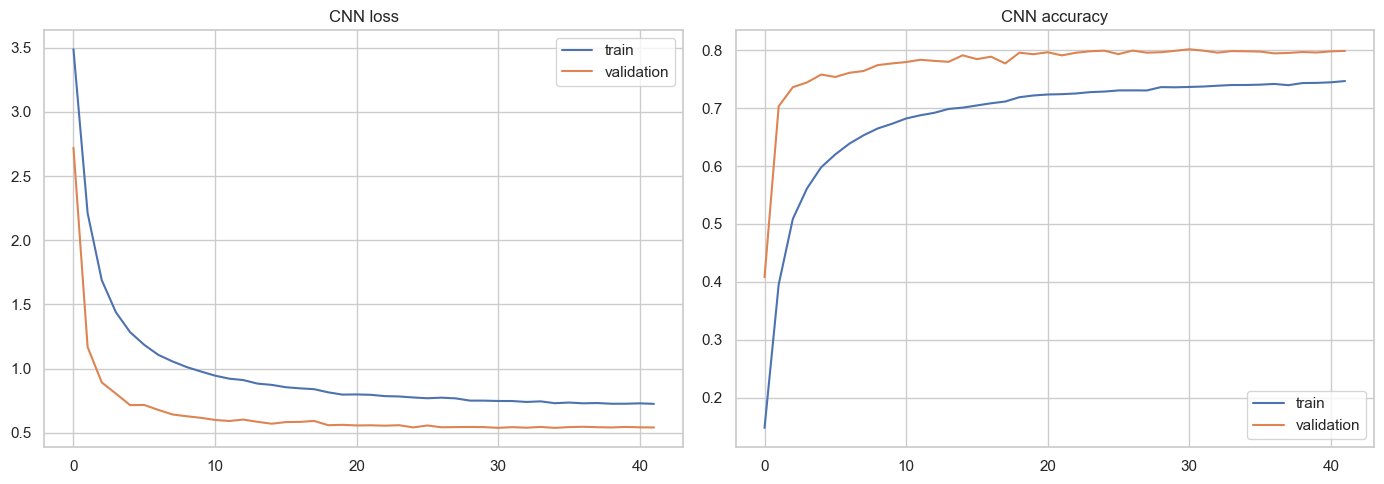

In [8]:
history_df = pd.DataFrame(history.history)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_df['loss'], label='train')
axes[0].plot(history_df['val_loss'], label='validation')
axes[0].set_title('CNN loss')
axes[0].legend()

axes[1].plot(history_df['accuracy'], label='train')
axes[1].plot(history_df['val_accuracy'], label='validation')
axes[1].set_title('CNN accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Final Evaluation

We evaluate the selected model on the held-out test split using accuracy, precision, recall, and F1-score. This is the main quantitative result for the OCR system.

The confusion matrix helps identify which characters are most often confused and whether the mistakes are concentrated among visually similar classes.


,split,accuracy,precision_macro,recall_macro,f1_macro
0,test,0.79955,0.703716,0.761169,0.712416


              precision    recall  f1-score   support

           0       0.71      0.66      0.68       993
           1       0.72      0.61      0.66      1088
           2       0.98      0.82      0.89      1009
           3       1.00      0.99      0.99      1026
           4       0.98      0.93      0.96       966
           5       0.93      0.93      0.93       892
           6       0.99      0.90      0.95       981
           7       0.98      0.97      0.98      1056
           8       0.99      0.93      0.96       969
           9       0.95      0.93      0.94       978
           A       0.90      0.96      0.93       183
           B       0.75      0.96      0.84       111
           C       0.84      0.43      0.57       299
           D       0.64      0.97      0.77       134
           E       0.90      0.97      0.93       146
           F       0.89      0.53      0.67       248
           G       0.71      1.00      0.83        77
           H       0.75    

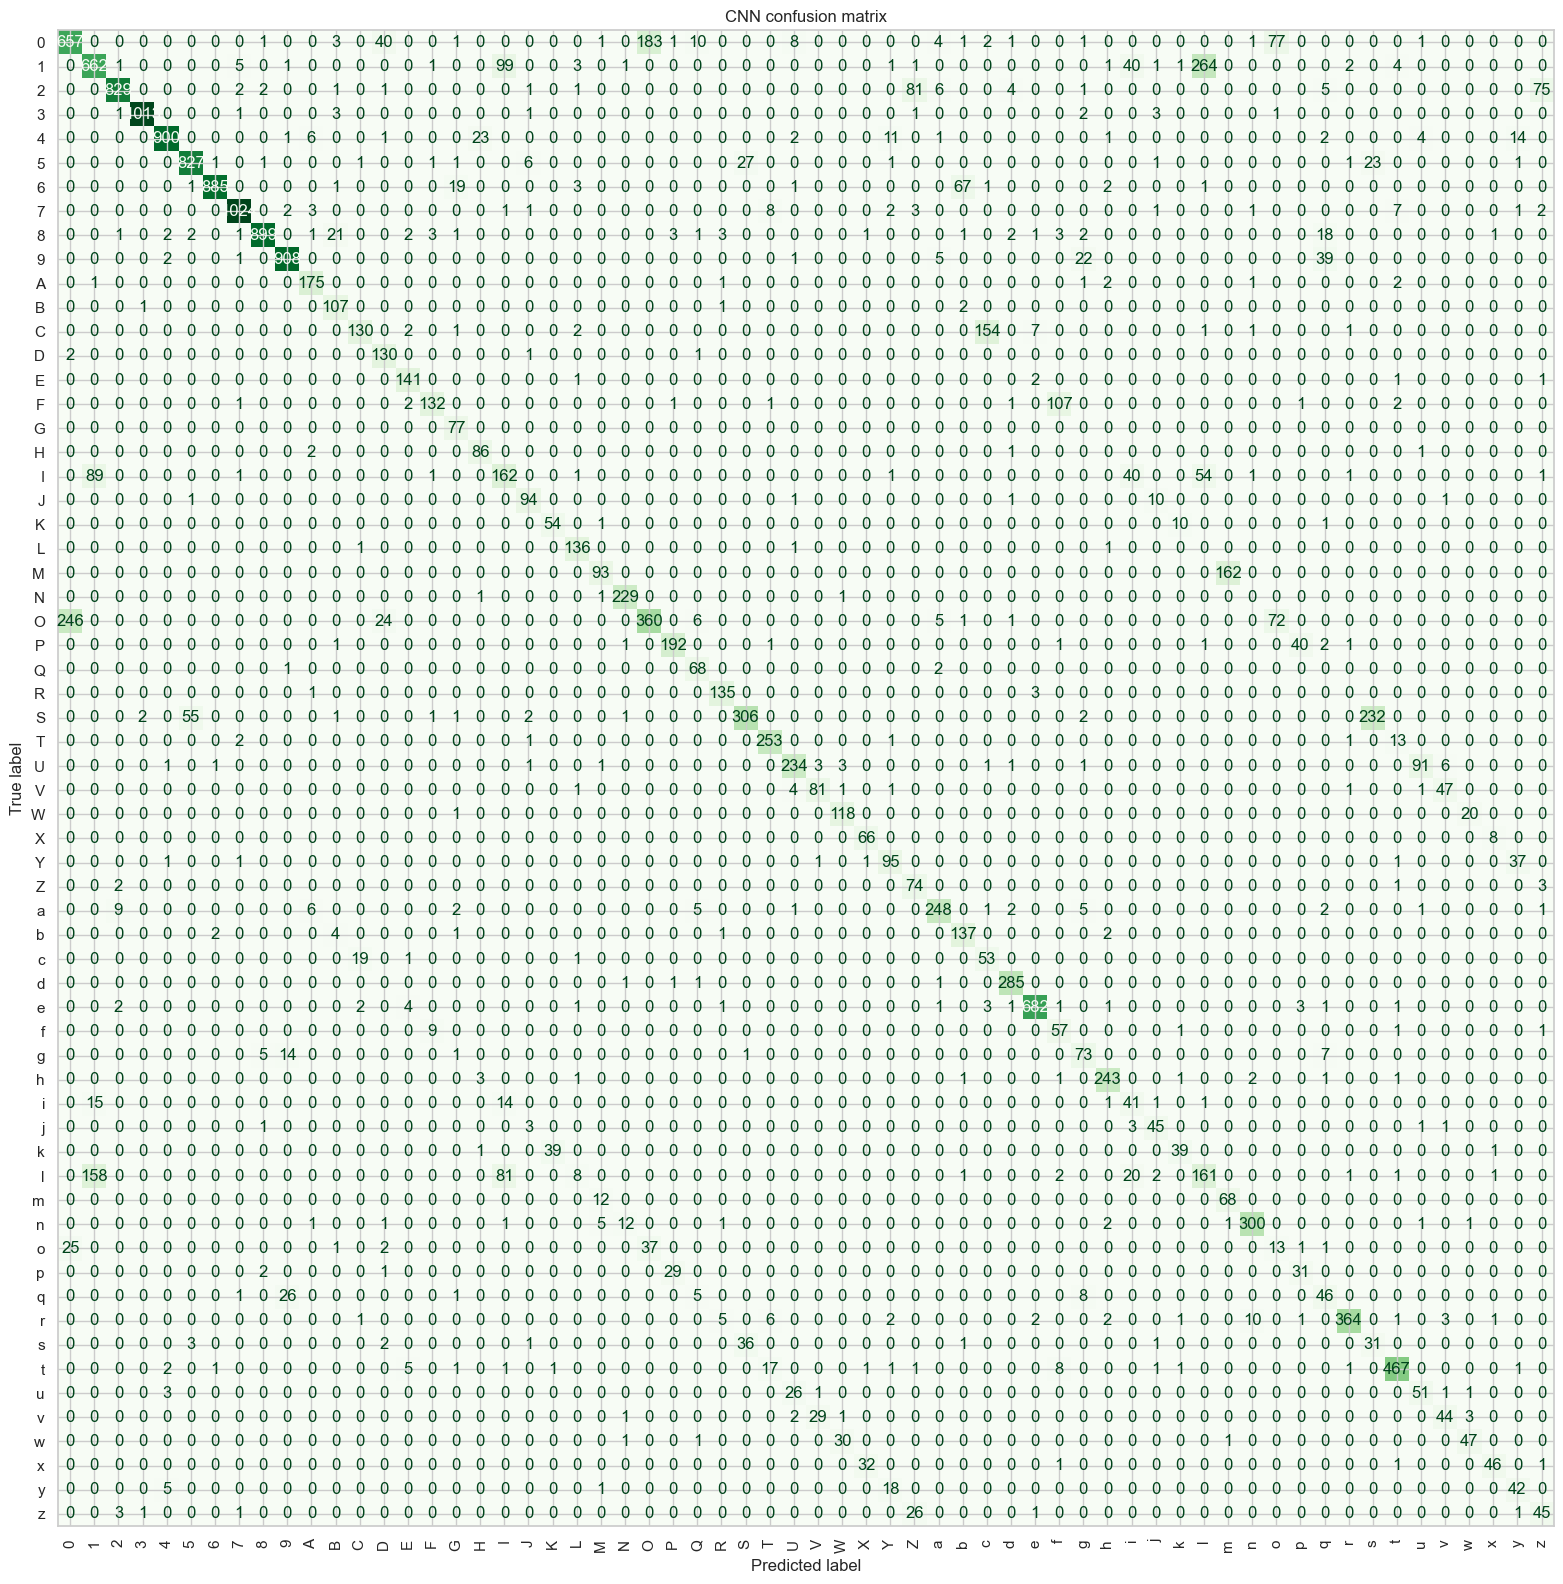

,model,accuracy,f1_macro
0,baseline,0.50460,0.374214
1,cnn,0.79955,0.712416


In [9]:
# Final evaluation on the held-out test split.
cnn_test_proba = cnn.predict(x_test_cnn, batch_size=256, verbose=0)
cnn_test_pred = np.argmax(cnn_test_proba, axis=1)

cnn_metrics = {
    'split': ['test'],
    'accuracy': [accuracy_score(y_test_subset, cnn_test_pred)],
    'precision_macro': [precision_score(y_test_subset, cnn_test_pred, average='macro', zero_division=0)],
    'recall_macro': [recall_score(y_test_subset, cnn_test_pred, average='macro', zero_division=0)],
    'f1_macro': [f1_score(y_test_subset, cnn_test_pred, average='macro', zero_division=0)],
}

display(pd.DataFrame(cnn_metrics))
print(classification_report(y_test_subset, cnn_test_pred, target_names=label_names, zero_division=0))

cm_cnn = confusion_matrix(y_test_subset, cnn_test_pred, labels=np.arange(num_classes))
fig, ax = plt.subplots(figsize=(18, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=label_names)
disp.plot(ax=ax, cmap='Greens', colorbar=False, values_format='.0f')
plt.xticks(rotation=90)
plt.title('CNN confusion matrix')
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    'model': ['baseline', 'cnn'],
    'accuracy': [accuracy_score(y_test_subset, test_baseline_pred), accuracy_score(y_test_subset, cnn_test_pred)],
    'f1_macro': [f1_score(y_test_subset, test_baseline_pred, average='macro', zero_division=0), f1_score(y_test_subset, cnn_test_pred, average='macro', zero_division=0)],
})
display(comparison)


## 10. Error Analysis

Accuracy alone does not tell us where the model struggles. Here we inspect the most common confusions and a sample of misclassified images to understand failure modes and possible improvements.


Top CNN confusions:
1 -> l: 264
O -> 0: 246
S -> s: 232
0 -> O: 183
M -> m: 162
l -> 1: 158
C -> c: 154
F -> f: 107
1 -> I: 99
U -> u: 91
I -> 1: 89
l -> I: 81
2 -> Z: 81
0 -> o: 77
2 -> z: 75


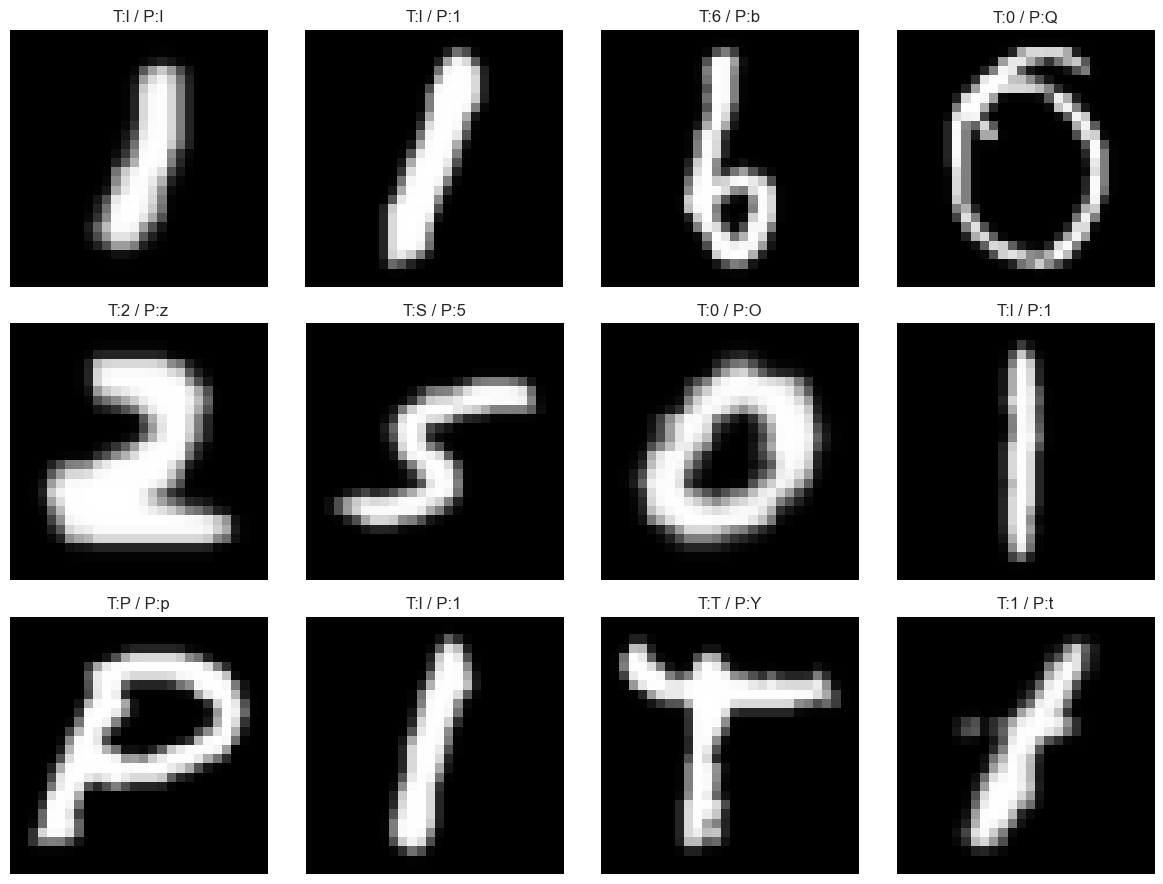

In [10]:
# Error analysis: inspect the most frequent confusions and a few misclassified samples.
def top_confusions(cm, names, top_n=15):
    pairs = []
    for true_idx in range(cm.shape[0]):
        for pred_idx in range(cm.shape[1]):
            if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
                pairs.append((cm[true_idx, pred_idx], names[true_idx], names[pred_idx]))
    return sorted(pairs, reverse=True)[:top_n]


print('Top CNN confusions:')
for count, true_name, pred_name in top_confusions(cm_cnn, label_names):
    print(f'{true_name} -> {pred_name}: {count}')

wrong_idx = np.where(y_test_subset != cnn_test_pred)[0]
if len(wrong_idx) > 0:
    rng = np.random.default_rng(42)
    picks = rng.choice(wrong_idx, size=min(12, len(wrong_idx)), replace=False)
    cols = 4
    rows = int(np.ceil(len(picks) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).reshape(-1)
    for ax, idx in zip(axes, picks):
        ax.imshow(x_test_subset[idx], cmap='gray')
        ax.set_title(f"T:{label_names[int(y_test_subset[idx])]} / P:{label_names[int(cnn_test_pred[idx])]}")
        ax.axis('off')
    for ax in axes[len(picks):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('No misclassified samples were found in the selected test subset.')


## 10.1 Integrated Gradients and Occlusion Heatmaps

To better understand how the two models behave, we compare a linear contribution map for the baseline with two more reliable explanation methods for the CNN: Integrated Gradients and occlusion sensitivity.

These methods are less noisy than a raw gradient saliency map and should better highlight the pixels that actually support the character prediction.


[    0     8     9 ... 19987 19990 19991]


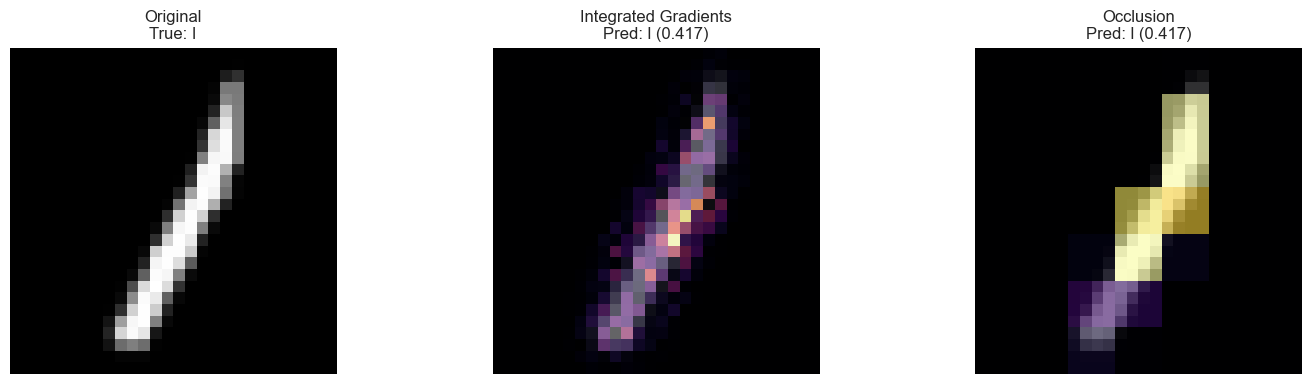

In [11]:
def normalize_map(arr):
    arr = np.asarray(arr, dtype=np.float32)
    arr = np.abs(arr)
    arr -= arr.min()
    if arr.max() > 0:
        arr /= arr.max()
    return arr


def integrated_gradients_map(model, image, class_idx=None, steps=32):
    image = prepare_cnn_input(image)
    baseline = np.zeros_like(image, dtype=np.float32)

    image_tensor = tf.convert_to_tensor(image[None, ...], dtype=tf.float32)
    baseline_tensor = tf.convert_to_tensor(baseline[None, ...], dtype=tf.float32)
    original_pred = model(image_tensor, training=False)[0]
    if class_idx is None:
        class_idx = int(tf.argmax(original_pred).numpy())

    alphas = tf.linspace(0.0, 1.0, steps + 1)[1:]
    interpolated = baseline_tensor + alphas[:, None, None, None] * (image_tensor - baseline_tensor)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated, training=False)
        scores = preds[:, class_idx]

    grads = tape.gradient(scores, interpolated).numpy()
    avg_grads = grads.mean(axis=0)
    ig = np.sum((image - baseline) * avg_grads, axis=-1)
    ig = normalize_map(ig)
    return ig, class_idx, float(original_pred[class_idx].numpy())


def occlusion_map(model, image, class_idx=None, patch_size=4, stride=4):
    image = np.asarray(image, dtype=np.float32)
    base_input = prepare_cnn_input(image)[None, ...]
    base_pred = model(base_input, training=False)[0].numpy()
    if class_idx is None:
        class_idx = int(np.argmax(base_pred))

    base_score = float(base_pred[class_idx])
    masked_images = []
    boxes = []
    h, w = image.shape

    for y in range(0, h, stride):
        for x in range(0, w, stride):
            y2 = min(y + patch_size, h)
            x2 = min(x + patch_size, w)
            masked = image.copy()
            masked[y:y2, x:x2] = 0.0
            masked_images.append(prepare_cnn_input(masked))
            boxes.append((y, y2, x, x2))

    masked_batch = np.stack(masked_images)
    masked_preds = model.predict(masked_batch, verbose=0)[:, class_idx]
    heatmap = np.zeros_like(image, dtype=np.float32)
    counts = np.zeros_like(image, dtype=np.float32)

    for score, (y, y2, x, x2) in zip(masked_preds, boxes):
        drop = base_score - float(score)
        heatmap[y:y2, x:x2] += drop
        counts[y:y2, x:x2] += 1.0

    heatmap = np.divide(heatmap, counts, out=np.zeros_like(heatmap), where=counts > 0)
    return normalize_map(heatmap), class_idx, base_score


def plot_cnn_explanation(cnn_model, images, labels, names, idx=0):
    ig_map, ig_pred, ig_conf = integrated_gradients_map(cnn_model, images[idx])
    occ_map, occ_pred, occ_conf = occlusion_map(cnn_model, images[idx])

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(images[idx], cmap='gray')
    axes[0].set_title(f"Original\nTrue: {names[int(labels[idx])]}")
    axes[0].axis('off')

    axes[1].imshow(images[idx], cmap='gray')
    axes[1].imshow(ig_map, cmap='inferno', alpha=0.6)
    axes[1].set_title(f"Integrated Gradients\nPred: {names[ig_pred]} ({ig_conf:.3f})")
    axes[1].axis('off')

    axes[2].imshow(images[idx], cmap='gray')
    axes[2].imshow(occ_map, cmap='inferno', alpha=0.6)
    axes[2].set_title(f"Occlusion\nPred: {names[occ_pred]} ({occ_conf:.3f})")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

print(wrong_idx)

sample_idx = int(wrong_idx[0]) if len(wrong_idx) > 0 else 0
plot_cnn_explanation(cnn, x_test_subset, y_test_subset, label_names, idx=sample_idx)


## 10.2 Baseline vs CNN Comparison Gallery

This extra view compares the linear baseline and the CNN on multiple test characters. It helps show whether both models focus on the same strokes, and whether the CNN explanation methods stay centered on the glyph instead of drifting into the background.


Comparison examples: [(1987, '9'), (14674, '4'), (10944, 'U'), (15249, '9'), (9302, '8'), (8625, 'O')]


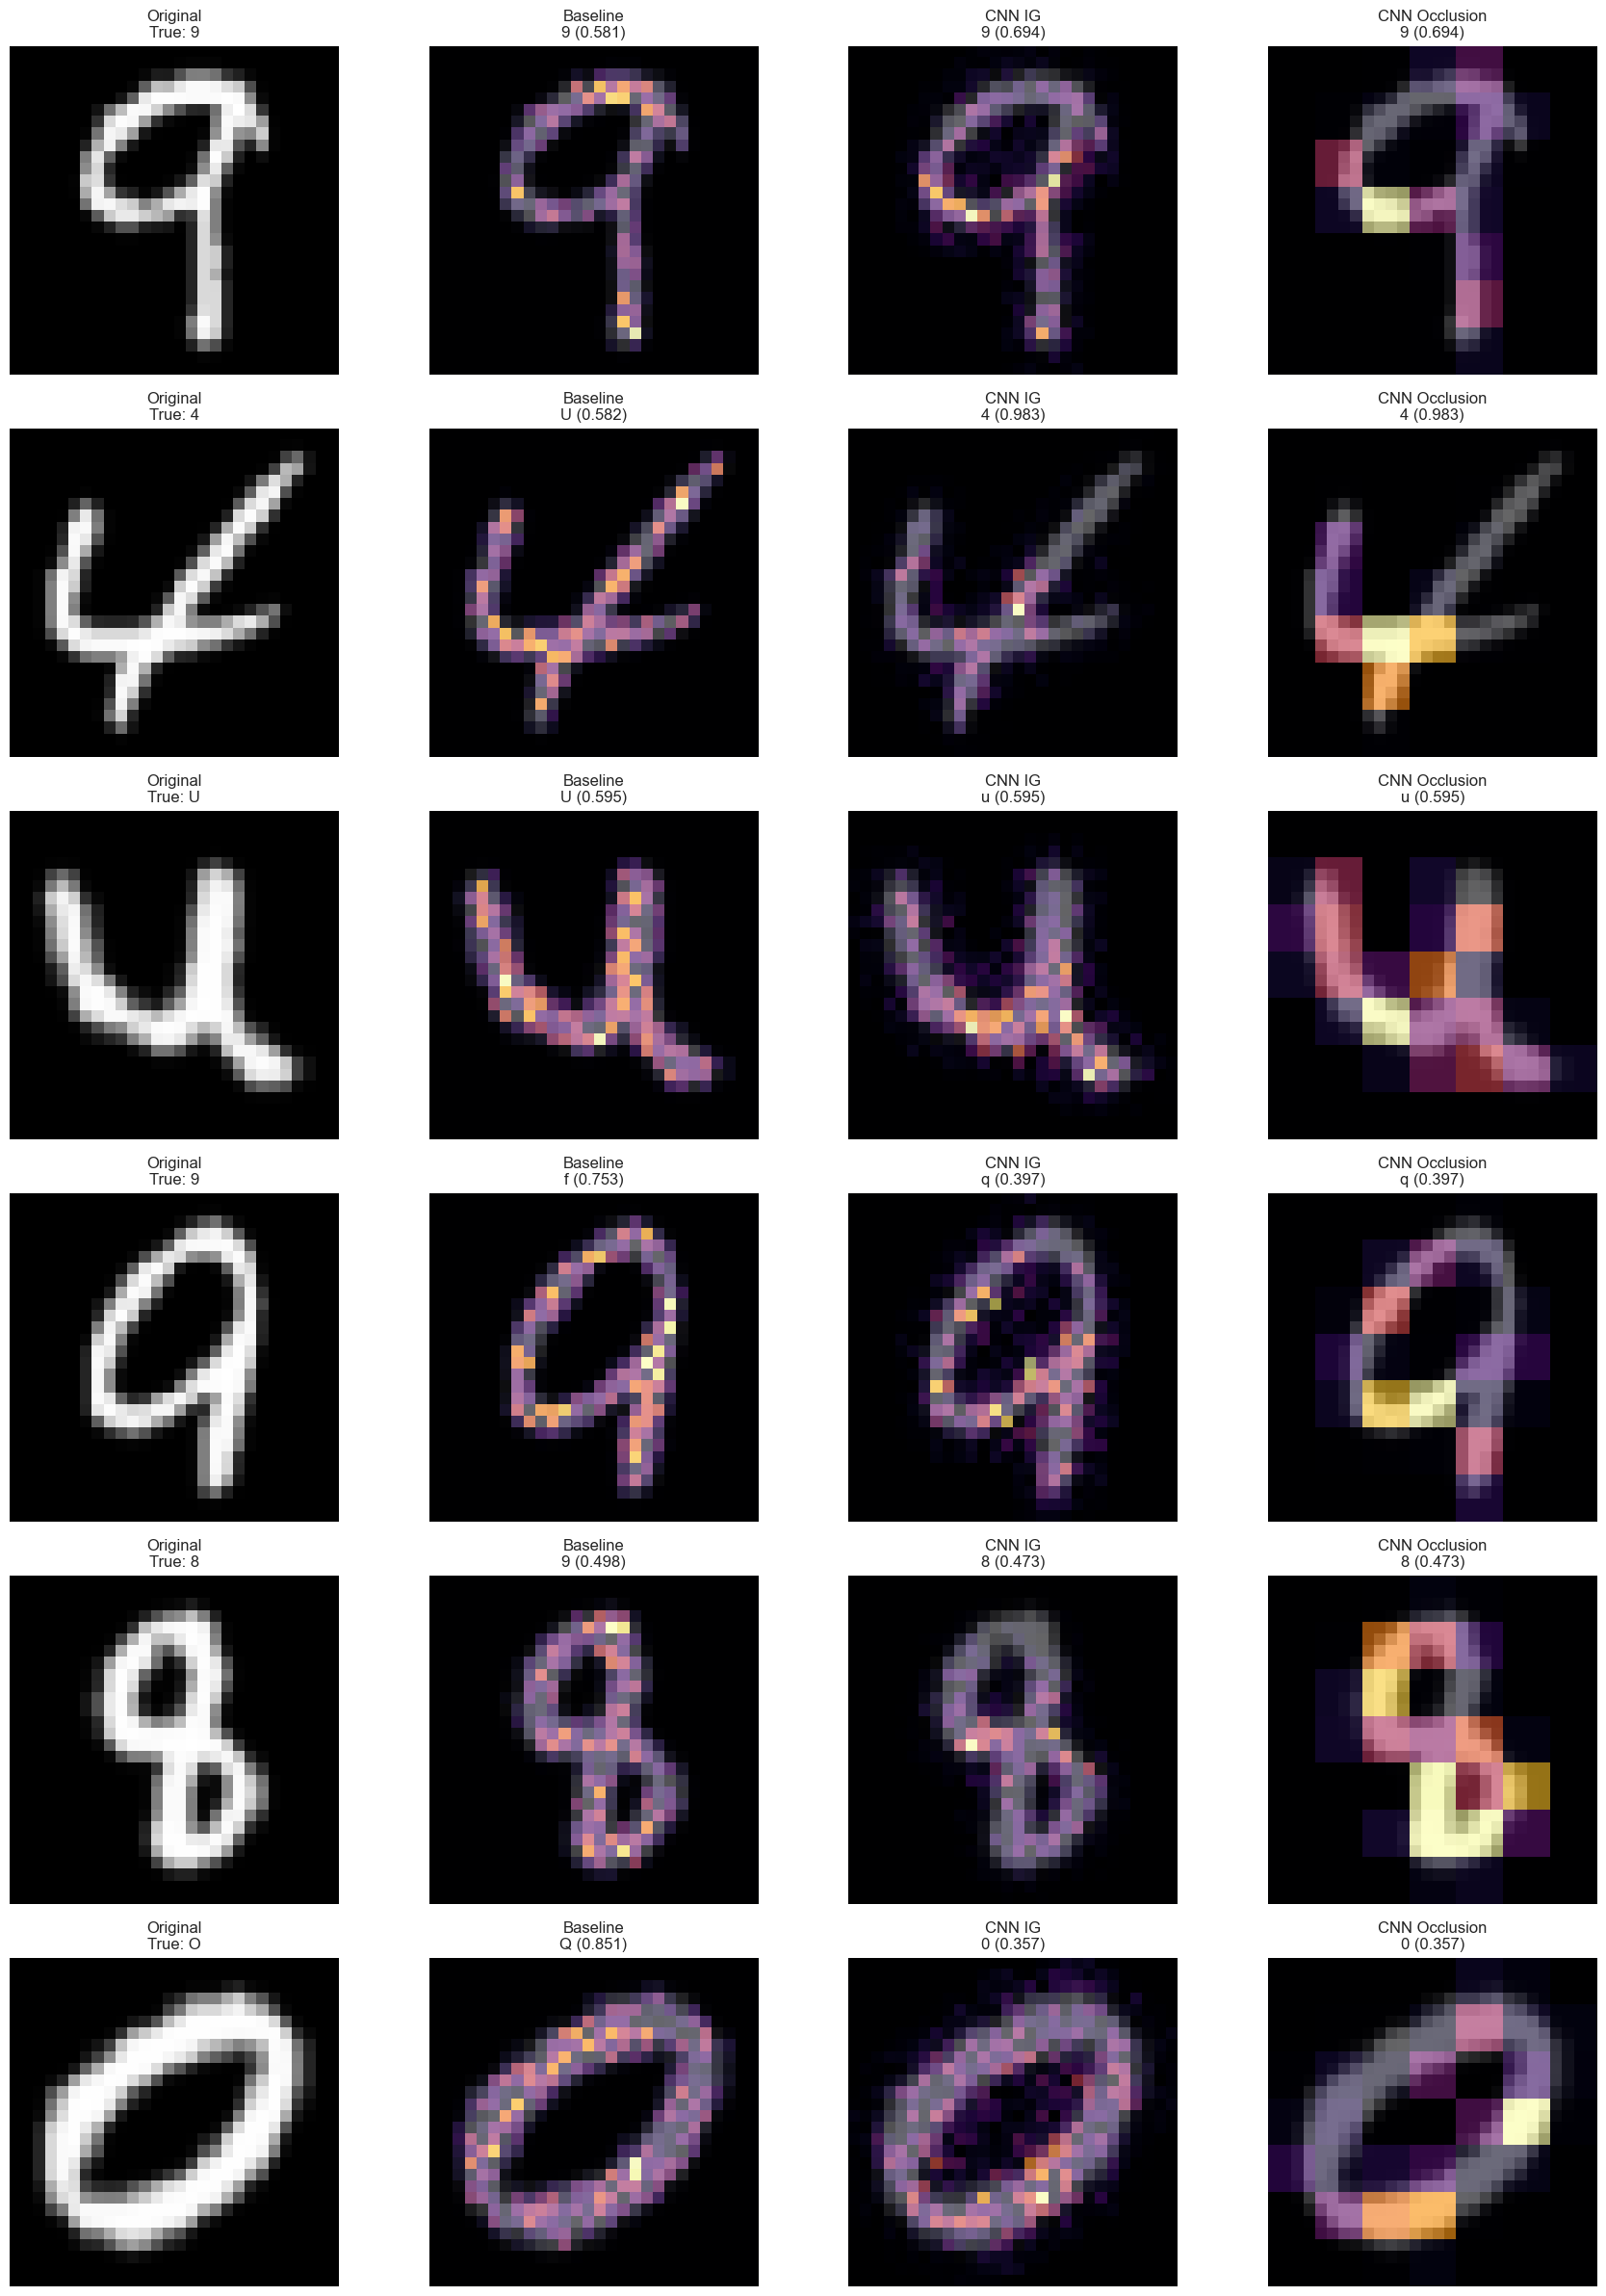

Selected comparison examples:
Index: 1987, True: 9, Baseline: 9 (0.581), CNN: 9 (0.694)
Index: 14674, True: 4, Baseline: U (0.582), CNN: 4 (0.983)
Index: 10944, True: U, Baseline: U (0.595), CNN: u (0.595)
Index: 15249, True: 9, Baseline: f (0.753), CNN: q (0.397)
Index: 9302, True: 8, Baseline: 9 (0.498), CNN: 8 (0.473)
Index: 8625, True: O, Baseline: Q (0.851), CNN: 0 (0.357)


In [12]:
def normalize_map(arr):
    arr = np.asarray(arr, dtype=np.float32)
    arr = np.abs(arr)
    arr -= arr.min()
    if arr.max() > 0:
        arr /= arr.max()
    return arr


def baseline_saliency_map(model, image, class_idx=None):
    image = np.asarray(image, dtype=np.float32)
    flat = image.reshape(-1)
    proba = model.predict_proba(flat[np.newaxis, :])[0]
    if class_idx is None:
        class_idx = int(np.argmax(proba))
    contrib = np.abs(model.coef_[class_idx] * flat).reshape(image.shape)
    return normalize_map(contrib), class_idx, float(proba[class_idx])


def integrated_gradients_map(model, image, class_idx=None, steps=32):
    image = prepare_cnn_input(image)
    baseline = np.zeros_like(image, dtype=np.float32)
    image_tensor = tf.convert_to_tensor(image[None, ...], dtype=tf.float32)
    baseline_tensor = tf.convert_to_tensor(baseline[None, ...], dtype=tf.float32)
    original_pred = model(image_tensor, training=False)[0]
    if class_idx is None:
        class_idx = int(tf.argmax(original_pred).numpy())

    alphas = tf.linspace(0.0, 1.0, steps + 1)[1:]
    interpolated = baseline_tensor + alphas[:, None, None, None] * (image_tensor - baseline_tensor)

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        preds = model(interpolated, training=False)
        scores = preds[:, class_idx]

    grads = tape.gradient(scores, interpolated).numpy()
    avg_grads = grads.mean(axis=0)
    ig = np.sum((image - baseline) * avg_grads, axis=-1)
    return normalize_map(ig), class_idx, float(original_pred[class_idx].numpy())


def occlusion_map(model, image, class_idx=None, patch_size=4, stride=4):
    image = np.asarray(image, dtype=np.float32)
    base_input = prepare_cnn_input(image)[None, ...]
    base_pred = model(base_input, training=False)[0].numpy()
    if class_idx is None:
        class_idx = int(np.argmax(base_pred))

    base_score = float(base_pred[class_idx])
    masked_images = []
    boxes = []
    h, w = image.shape

    for y in range(0, h, stride):
        for x in range(0, w, stride):
            y2 = min(y + patch_size, h)
            x2 = min(x + patch_size, w)
            masked = image.copy()
            masked[y:y2, x:x2] = 0.0
            masked_images.append(prepare_cnn_input(masked))
            boxes.append((y, y2, x, x2))

    masked_batch = np.stack(masked_images)
    masked_preds = model.predict(masked_batch, verbose=0)[:, class_idx]
    heatmap = np.zeros_like(image, dtype=np.float32)
    counts = np.zeros_like(image, dtype=np.float32)

    for score, (y, y2, x, x2) in zip(masked_preds, boxes):
        drop = base_score - float(score)
        heatmap[y:y2, x:x2] += drop
        counts[y:y2, x:x2] += 1.0

    heatmap = np.divide(heatmap, counts, out=np.zeros_like(heatmap), where=counts > 0)
    return normalize_map(heatmap), class_idx, base_score


def pick_example_indices(y_true, baseline_pred, cnn_pred, n=4, seed=1):
    rng = np.random.default_rng(seed)
    pools = [
        np.where((y_true == baseline_pred) & (y_true == cnn_pred))[0],
        np.where((y_true != baseline_pred) & (y_true == cnn_pred))[0],
        np.where((y_true == baseline_pred) & (y_true != cnn_pred))[0],
        np.where((y_true != baseline_pred) & (y_true != cnn_pred))[0],
    ]
    picked = []
    for pool in pools:
        if len(pool) == 0:
            continue
        picked.append(int(rng.choice(pool)))
        if len(picked) >= n:
            break
    if len(picked) < n:
        remaining = np.setdiff1d(np.arange(len(y_true)), np.array(picked, dtype=int), assume_unique=False)
        if len(remaining) > 0:
            extra = rng.choice(remaining, size=min(n - len(picked), len(remaining)), replace=False)
            picked.extend([int(i) for i in extra])
    return picked[:n]


def plot_comparison_gallery(baseline_model, cnn_model, images, labels, names, indices):
    rows = len(indices)
    fig, axes = plt.subplots(rows, 4, figsize=(18, 4 * rows))
    if rows == 1:
        axes = np.array([axes])

    for row, idx in enumerate(indices):
        base_map, base_pred, base_conf = baseline_saliency_map(baseline_model, images[idx])
        ig_map, ig_pred, ig_conf = integrated_gradients_map(cnn_model, images[idx])
        occ_map, occ_pred, occ_conf = occlusion_map(cnn_model, images[idx])

        ax = axes[row, 0]
        ax.imshow(images[idx], cmap='gray')
        ax.set_title(f"Original\nTrue: {names[int(labels[idx])]}")
        ax.axis('off')

        ax = axes[row, 1]
        ax.imshow(images[idx], cmap='gray')
        ax.imshow(base_map, cmap='inferno', alpha=0.6)
        ax.set_title(f"Baseline\n{names[base_pred]} ({base_conf:.3f})")
        ax.axis('off')

        ax = axes[row, 2]
        ax.imshow(images[idx], cmap='gray')
        ax.imshow(ig_map, cmap='inferno', alpha=0.6)
        ax.set_title(f"CNN IG\n{names[ig_pred]} ({ig_conf:.3f})")
        ax.axis('off')

        ax = axes[row, 3]
        ax.imshow(images[idx], cmap='gray')
        ax.imshow(occ_map, cmap='inferno', alpha=0.6)
        ax.set_title(f"CNN Occlusion\n{names[occ_pred]} ({occ_conf:.3f})")
        ax.axis('off')

    plt.tight_layout()
    plt.show()


comparison_indices = pick_example_indices(y_test_subset, test_baseline_pred, cnn_test_pred, n=6, seed=47)
print('Comparison examples:', [(idx, label_names[int(y_test_subset[idx])]) for idx in comparison_indices])
plot_comparison_gallery(baseline, cnn, x_test_subset, y_test_subset, label_names, comparison_indices)


print('Selected comparison examples:')
for idx in comparison_indices:
    baseline_conf = baseline.predict_proba(x_test_flat[idx].reshape(1, -1))[0][test_baseline_pred[idx]]
    cnn_conf = cnn_test_proba[idx][cnn_test_pred[idx]]
    print(
        f'Index: {idx}, True: {label_names[int(y_test_subset[idx])]}, '
        f'Baseline: {label_names[int(test_baseline_pred[idx])]} ({baseline_conf:.3f}), '
        f'CNN: {label_names[int(cnn_test_pred[idx])]} ({cnn_conf:.3f})')


## 11. Interactive Drawing Demo

The function defined below opens a small drawing window for manual testing. Draw a character, run prediction, and compare the result against the model output. This is a lightweight way to demonstrate the end-to-end OCR pipeline.

The drawn image is resized to `28 x 28` and inverted before prediction so it matches the training format.


In [58]:
def launch_drawing_app(model, names):
    try:
        import tkinter as tk
        from tkinter import messagebox
        from PIL import Image, ImageDraw, ImageOps
    except Exception as exc:
        print('Drawing window unavailable in this environment:', exc)
        return

    canvas_size = 280
    brush_size = 18
    bg_color = 'white'
    pen_color = 'black'

    root = tk.Tk()
    root.title('OCR Drawing Test')
    root.resizable(False, False)

    info = tk.Label(
        root,
        text='Draw a character, then click Predict. Use Clear to reset the canvas.',
        padx=10,
        pady=8,
    )
    info.pack()

    canvas = tk.Canvas(root, width=canvas_size, height=canvas_size, bg=bg_color, cursor='cross')
    canvas.pack(padx=10, pady=10)

    image = Image.new('L', (canvas_size, canvas_size), 255)
    draw = ImageDraw.Draw(image)
    last_x, last_y = None, None

    result_var = tk.StringVar(value='Prediction will appear here.')
    result_label = tk.Label(root, textvariable=result_var, font=('Arial', 14, 'bold'), pady=8)
    result_label.pack()

    button_frame = tk.Frame(root)
    button_frame.pack(pady=8)

    def paint(event):
        nonlocal last_x, last_y
        x, y = event.x, event.y
        if last_x is not None and last_y is not None:
            canvas.create_line(last_x, last_y, x, y, fill=pen_color, width=brush_size, capstyle=tk.ROUND, smooth=True)
            draw.line((last_x, last_y, x, y), fill=0, width=brush_size)
        last_x, last_y = x, y

    def reset(_event=None):
        nonlocal image, draw, last_x, last_y
        canvas.delete('all')
        canvas.configure(bg=bg_color)
        image = Image.new('L', (canvas_size, canvas_size), 255)
        draw = ImageDraw.Draw(image)
        last_x, last_y = None, None
        result_var.set('Prediction will appear here.')

    def predict():
        # Invert because the model was trained on dark backgrounds with bright strokes.
        img = image.copy()
        img = ImageOps.invert(img)
        img = img.resize((28, 28))
        arr = np.array(img, dtype=np.float32) / 255.0
        arr = prepare_cnn_input(arr)[None, ...]
        probs = model.predict(arr, verbose=0)[0]
        pred_idx = int(np.argmax(probs))
        pred_name = names[pred_idx]
        confidence = float(probs[pred_idx])
        result_var.set(f'Prediction: {pred_name}  |  confidence: {confidence:.3f}')

    def on_release(_event):
        nonlocal last_x, last_y
        last_x, last_y = None, None

    canvas.bind('<B1-Motion>', paint)
    canvas.bind('<ButtonRelease-1>', on_release)

    tk.Button(button_frame, text='Predict', width=14, command=predict).grid(row=0, column=0, padx=8)
    tk.Button(button_frame, text='Clear', width=14, command=reset).grid(row=0, column=1, padx=8)
    tk.Button(button_frame, text='Quit', width=14, command=root.destroy).grid(row=0, column=2, padx=8)

    root.bind('<Escape>', lambda _event: root.destroy())
    root.bind('c', reset)
    root.bind('p', lambda _event: predict())
    root.mainloop()


# Launch the drawing window.
launch_drawing_app(cnn, label_names)


## 12. Model Diagnostics

This section extracts useful internals from the CNN and builds extra figures for the report: weight summaries, weight histograms, first-layer filters, per-class recall, and a few confident predictions.


,layer,tensor,shape,n_params,mean,std,min,max
0,conv2d,w0,"(3, 3, 2, 32)",576,-0.001859,0.092574,-0.217361,0.255753
1,batch_normalization,w0,"(32,)",32,0.938594,0.119176,0.663867,1.208123
2,batch_normalization,w1,"(32,)",32,-0.314702,0.080618,-0.445087,-0.118085
3,batch_normalization,w2,"(32,)",32,-0.021786,0.063381,-0.208267,0.250793
4,batch_normalization,w3,"(32,)",32,0.009105,0.014092,0.000519,0.071224
5,conv2d_1,w0,"(3, 3, 32, 64)",18432,-0.008431,0.070014,-0.355611,0.263319
6,batch_normalization_1,w0,"(64,)",64,0.971626,0.079681,0.759321,1.200684
7,batch_normalization_1,w1,"(64,)",64,-0.260991,0.063072,-0.397095,-0.091294
8,batch_normalization_1,w2,"(64,)",64,-0.526862,0.400049,-1.701617,0.402613
9,batch_normalization_1,w3,"(64,)",64,0.903923,0.307240,0.424882,1.918370


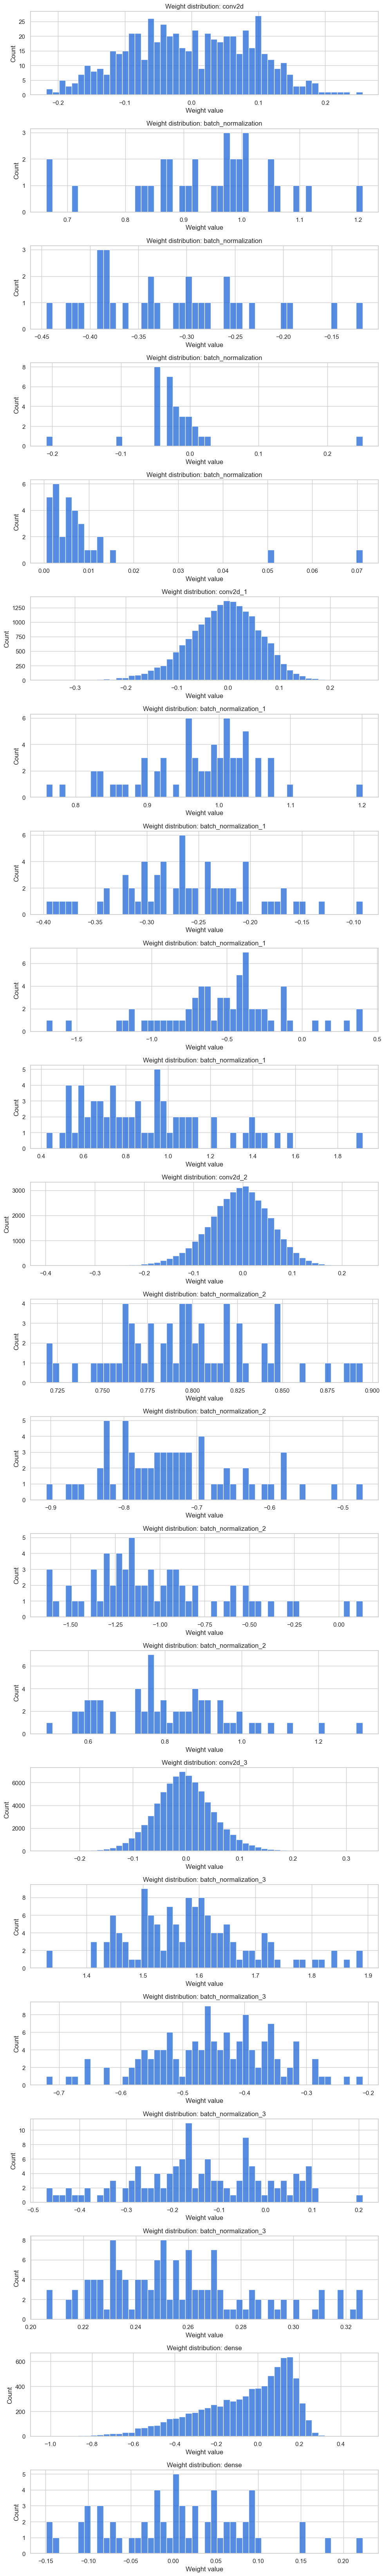

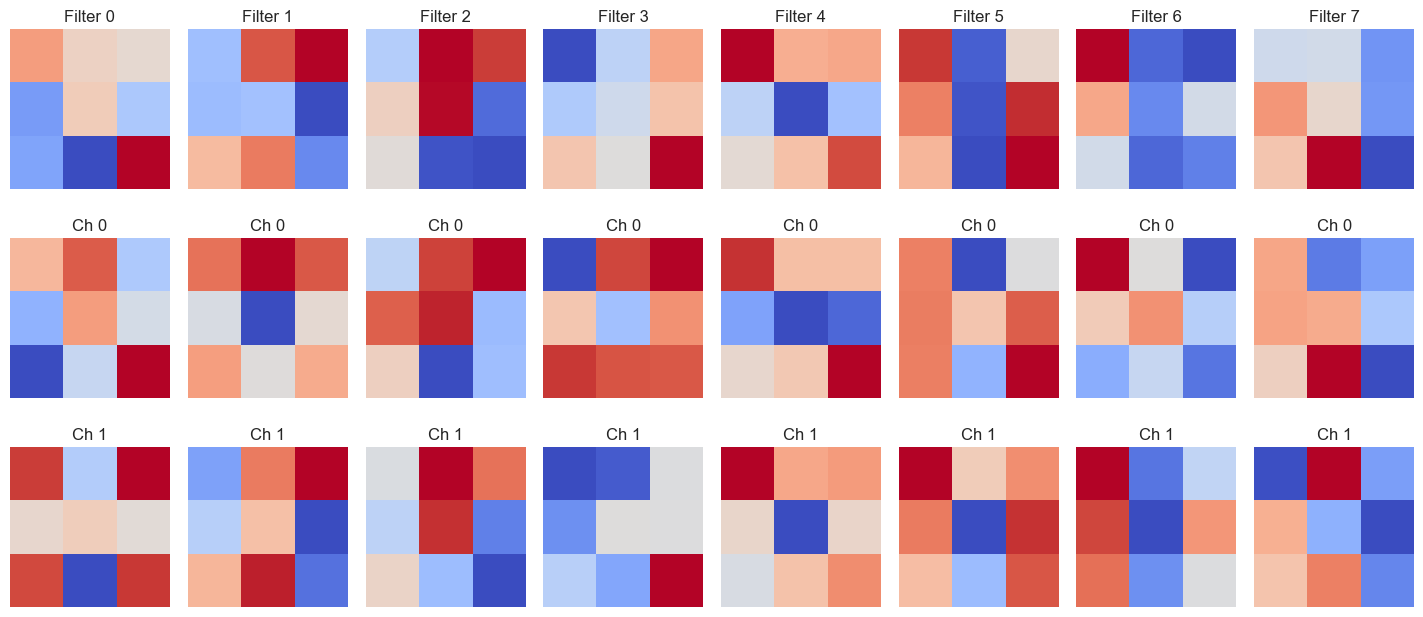

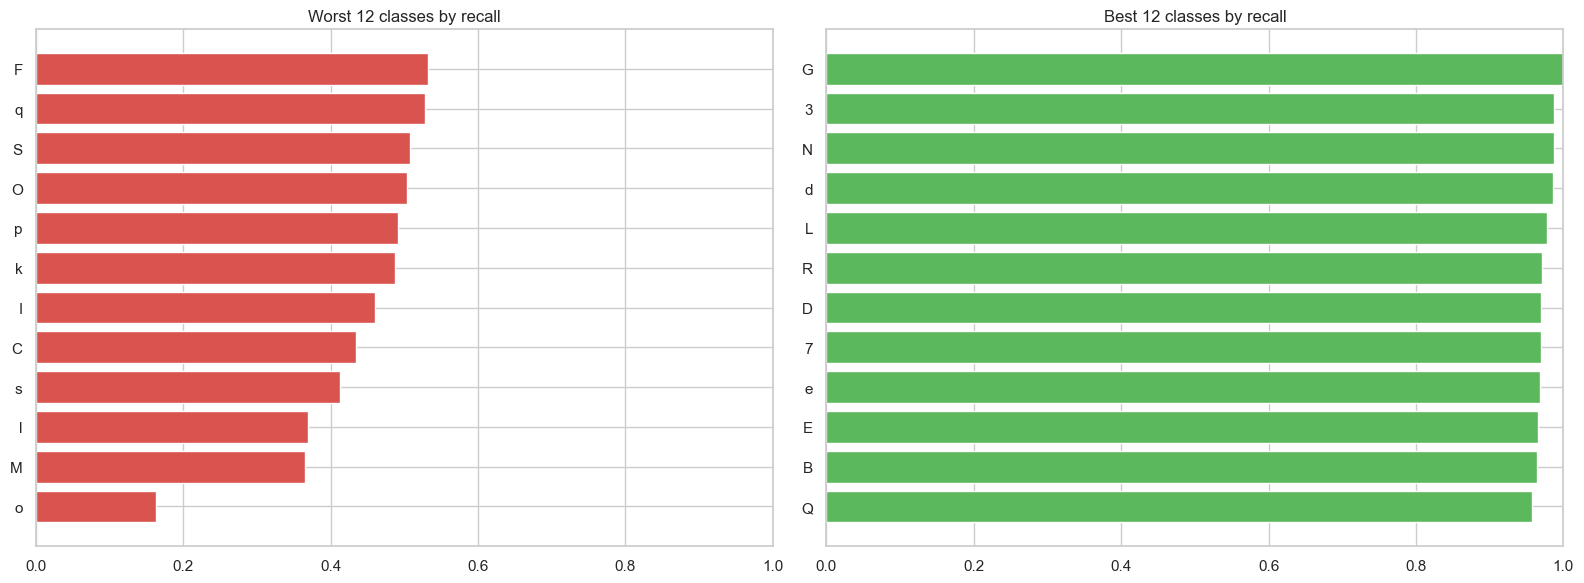

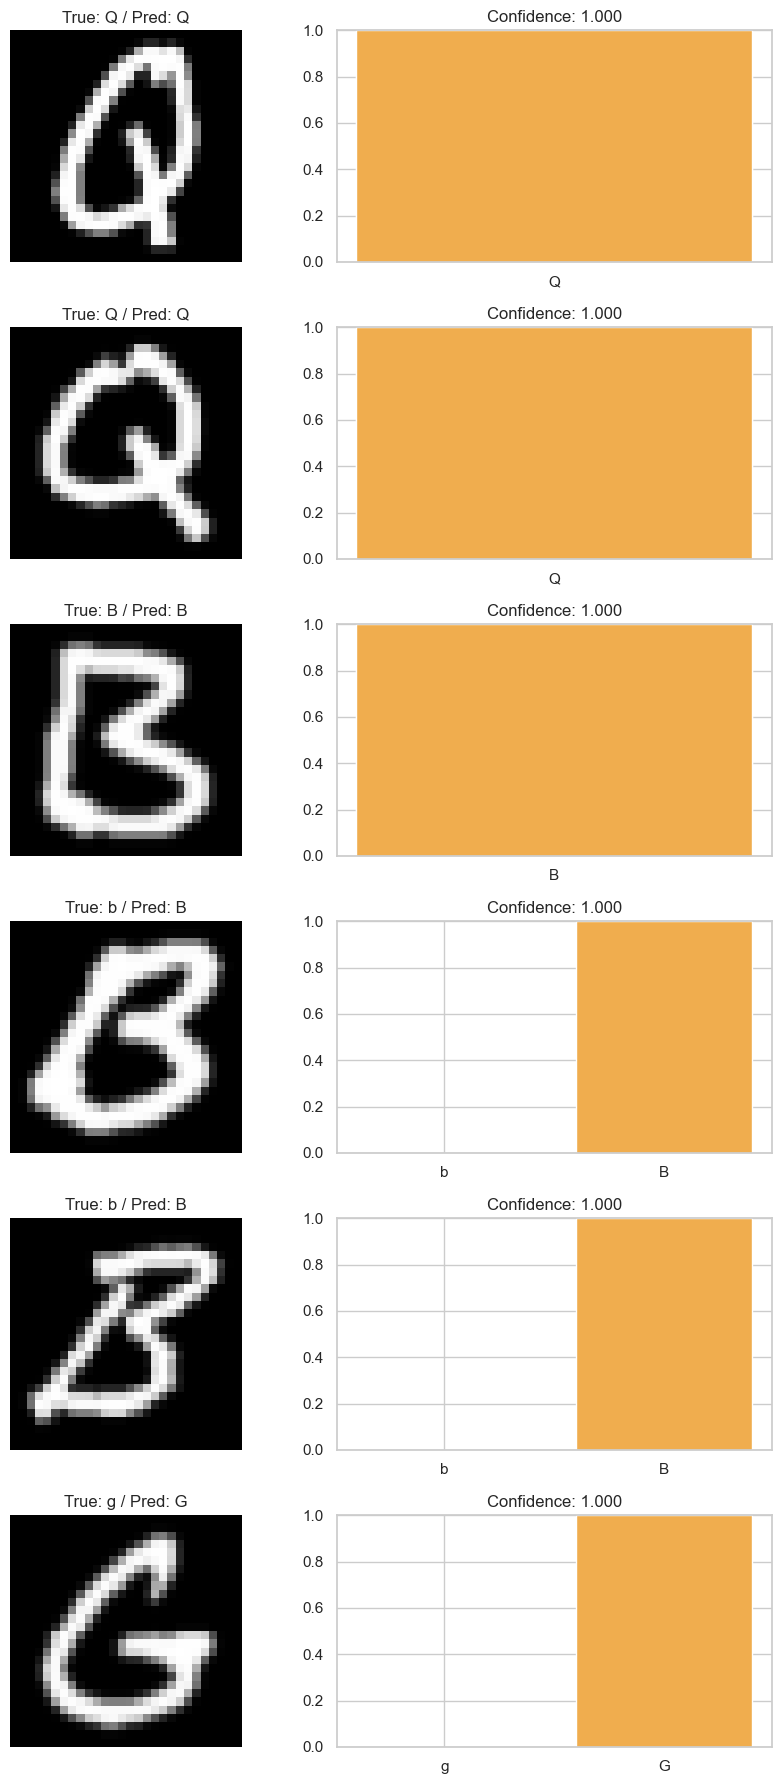

In [59]:
def summarize_cnn_weights(model):
    rows = []
    for layer in model.layers:
        weights = layer.get_weights()
        if not weights:
            continue
        for idx, arr in enumerate(weights):
            arr = np.asarray(arr)
            rows.append({
                'layer': layer.name,
                'tensor': f'w{idx}',
                'shape': str(arr.shape),
                'n_params': int(arr.size),
                'mean': float(arr.mean()),
                'std': float(arr.std()),
                'min': float(arr.min()),
                'max': float(arr.max()),
            })
    return pd.DataFrame(rows)


def plot_weight_histograms(model):
    weight_blocks = []
    for layer in model.layers:
        for arr in layer.get_weights():
            arr = np.asarray(arr).ravel()
            if arr.size > 0:
                weight_blocks.append((layer.name, arr))

    if not weight_blocks:
        print('No trainable weights found.')
        return

    fig, axes = plt.subplots(len(weight_blocks), 1, figsize=(10, 3 * len(weight_blocks)))
    if len(weight_blocks) == 1:
        axes = [axes]
    for ax, (layer_name, values) in zip(axes, weight_blocks):
        ax.hist(values, bins=50, color='#2a6fdb', alpha=0.8)
        ax.set_title(f'Weight distribution: {layer_name}')
        ax.set_xlabel('Weight value')
        ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


def plot_first_conv_filters(model, max_filters=8):
    conv_layer = next((layer for layer in model.layers if isinstance(layer, keras.layers.Conv2D)), None)
    if conv_layer is None:
        print('No Conv2D layer found.')
        return

    kernel = conv_layer.get_weights()[0]
    n_filters = min(kernel.shape[-1], max_filters)
    n_channels = kernel.shape[2]
    fig, axes = plt.subplots(n_channels + 1, n_filters, figsize=(1.8 * n_filters, 2.2 * (n_channels + 1)))
    if n_filters == 1:
        axes = np.expand_dims(axes, axis=1)

    for f in range(n_filters):
        combined = kernel[:, :, :, f].mean(axis=2)
        axes[0, f].imshow(combined, cmap='coolwarm')
        axes[0, f].set_title(f'Filter {f}')
        axes[0, f].axis('off')
        for c in range(n_channels):
            axes[c + 1, f].imshow(kernel[:, :, c, f], cmap='coolwarm')
            axes[c + 1, f].set_title(f'Ch {c}')
            axes[c + 1, f].axis('off')

    plt.tight_layout()
    plt.show()


def plot_per_class_recall(cm, names, top_n=12):
    per_class = np.divide(np.diag(cm), cm.sum(axis=1), out=np.zeros(cm.shape[0], dtype=float), where=cm.sum(axis=1) > 0)
    order = np.argsort(per_class)
    worst = order[:top_n]
    best = order[-top_n:][::-1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].barh([names[i] for i in worst], per_class[worst], color='#d9534f')
    axes[0].set_title(f'Worst {top_n} classes by recall')
    axes[0].set_xlim(0, 1)

    axes[1].barh([names[i] for i in best[::-1]], per_class[best[::-1]], color='#5cb85c')
    axes[1].set_title(f'Best {top_n} classes by recall')
    axes[1].set_xlim(0, 1)
    plt.tight_layout()
    plt.show()


def plot_confident_examples(images, labels, preds, proba, names, n=6):
    confidence = proba.max(axis=1)
    correct = np.where(preds == labels)[0]
    wrong = np.where(preds != labels)[0]
    picks = []
    if len(correct) > 0:
        picks.extend(correct[np.argsort(confidence[correct])[-min(3, len(correct)):]][::-1].tolist())
    if len(wrong) > 0:
        picks.extend(wrong[np.argsort(confidence[wrong])[-min(3, len(wrong)):]][::-1].tolist())
    picks = picks[:n]

    rows = len(picks)
    fig, axes = plt.subplots(rows, 2, figsize=(9, 3 * rows))
    if rows == 1:
        axes = np.array([axes])

    for row, idx in enumerate(picks):
        axes[row, 0].imshow(images[idx], cmap='gray')
        axes[row, 0].axis('off')
        axes[row, 0].set_title(f'True: {names[int(labels[idx])]} / Pred: {names[int(preds[idx])]}')

        classes = [names[int(labels[idx])], names[int(preds[idx])]]
        values = [float(proba[idx, labels[idx]]), float(confidence[idx])]
        axes[row, 1].bar(classes, values, color=['#5bc0de', '#f0ad4e'])
        axes[row, 1].set_ylim(0, 1)
        axes[row, 1].set_title(f'Confidence: {confidence[idx]:.3f}')

    plt.tight_layout()
    plt.show()


weights_df = summarize_cnn_weights(cnn)
display(weights_df)
plot_weight_histograms(cnn)
plot_first_conv_filters(cnn, max_filters=8)
plot_per_class_recall(cm_cnn, label_names, top_n=12)
plot_confident_examples(x_test_subset, y_test_subset, cnn_test_pred, cnn_test_proba, label_names, n=6)


## 13. Report Notes

Use this notebook as the technical backbone of the written report. The most relevant points to discuss are:

- the dataset format and class distribution
- examples of preprocessed handwritten characters
- why normalization, reshaping, and validation splitting are necessary
- the difference between the baseline classifier and the CNN
- the most important confusions shown by the error analysis
- limitations of the current model and realistic next steps such as augmentation, deeper architectures, or language-model post-processing


# Advanced AI LAB

## 1. Security

We focus on the most common OCR failure modes: class imbalance, top confusions, and sensitivity to realistic image perturbations.
The goal is to test whether the CNN remains stable on ambiguous handwritten characters such as `O` vs `0` and `I` vs `1`.


,class,support,recall
0,o,80,0.162500
1,M,255,0.364706
2,l,436,0.369266
3,s,75,0.413333
4,C,299,0.434783
5,I,352,0.460227
6,k,80,0.487500
7,p,63,0.492063
8,O,715,0.503497
9,S,603,0.507463


,true_label,pred_label,count
0,1,l,264
1,O,0,246
2,S,s,232
3,0,O,183
4,M,m,162
5,l,1,158
6,C,c,154
7,F,f,107
8,1,I,99
9,U,u,91


,true_label,pred_label,count
0,1,l,264
1,O,0,246
2,0,O,183
3,l,1,158
4,1,I,99
5,I,1,89
6,l,I,81
7,0,o,77
8,O,o,72
9,I,l,54


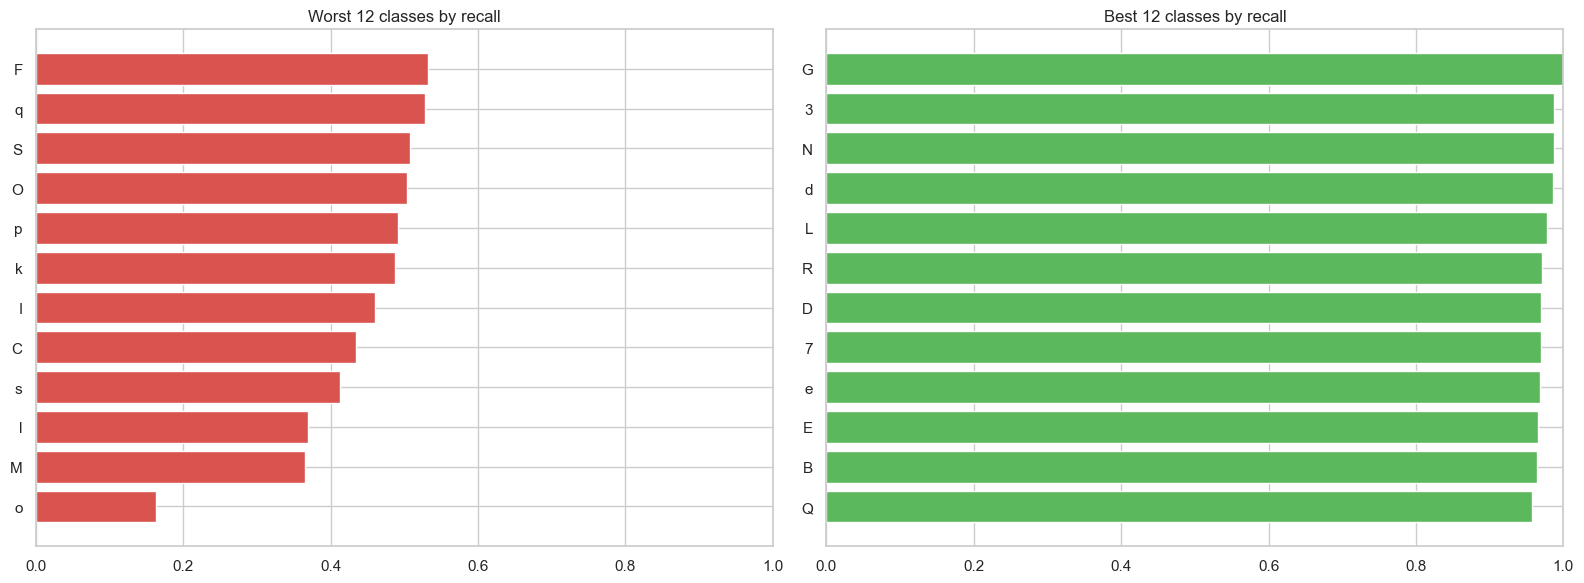

In [60]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_dir = Path.cwd()
if not (project_dir / 'advanced_ai_utils.py').exists():
    candidate = project_dir / 'Project2026'
    if (candidate / 'advanced_ai_utils.py').exists():
        sys.path.append(str(candidate))

from advanced_ai_utils import (
    confidence_sweep,
    per_class_recall_table,
    top_confusion_pairs,
    perturb_image,
)

def cnn_predict_from_gray(image):
    """Predict on a single grayscale image using the 2-channel CNN input."""
    arr = prepare_cnn_input(image)[None, ...]
    return cnn.predict(arr, verbose=0)[0]

recall_table = per_class_recall_table(y_test_subset, cnn_test_pred, label_names)
confusion_table = top_confusion_pairs(cm_cnn, label_names, top_n=20)

display(recall_table.head(15))
display(confusion_table)

focus_mask = confusion_table['true_label'].isin(['O', '0', 'I', '1', 'l', 'o']) | confusion_table['pred_label'].isin(['O', '0', 'I', '1', 'l', 'o'])
focus_confusions = confusion_table.loc[focus_mask].reset_index(drop=True)
display(focus_confusions)

plot_per_class_recall(cm_cnn, label_names, top_n=12)


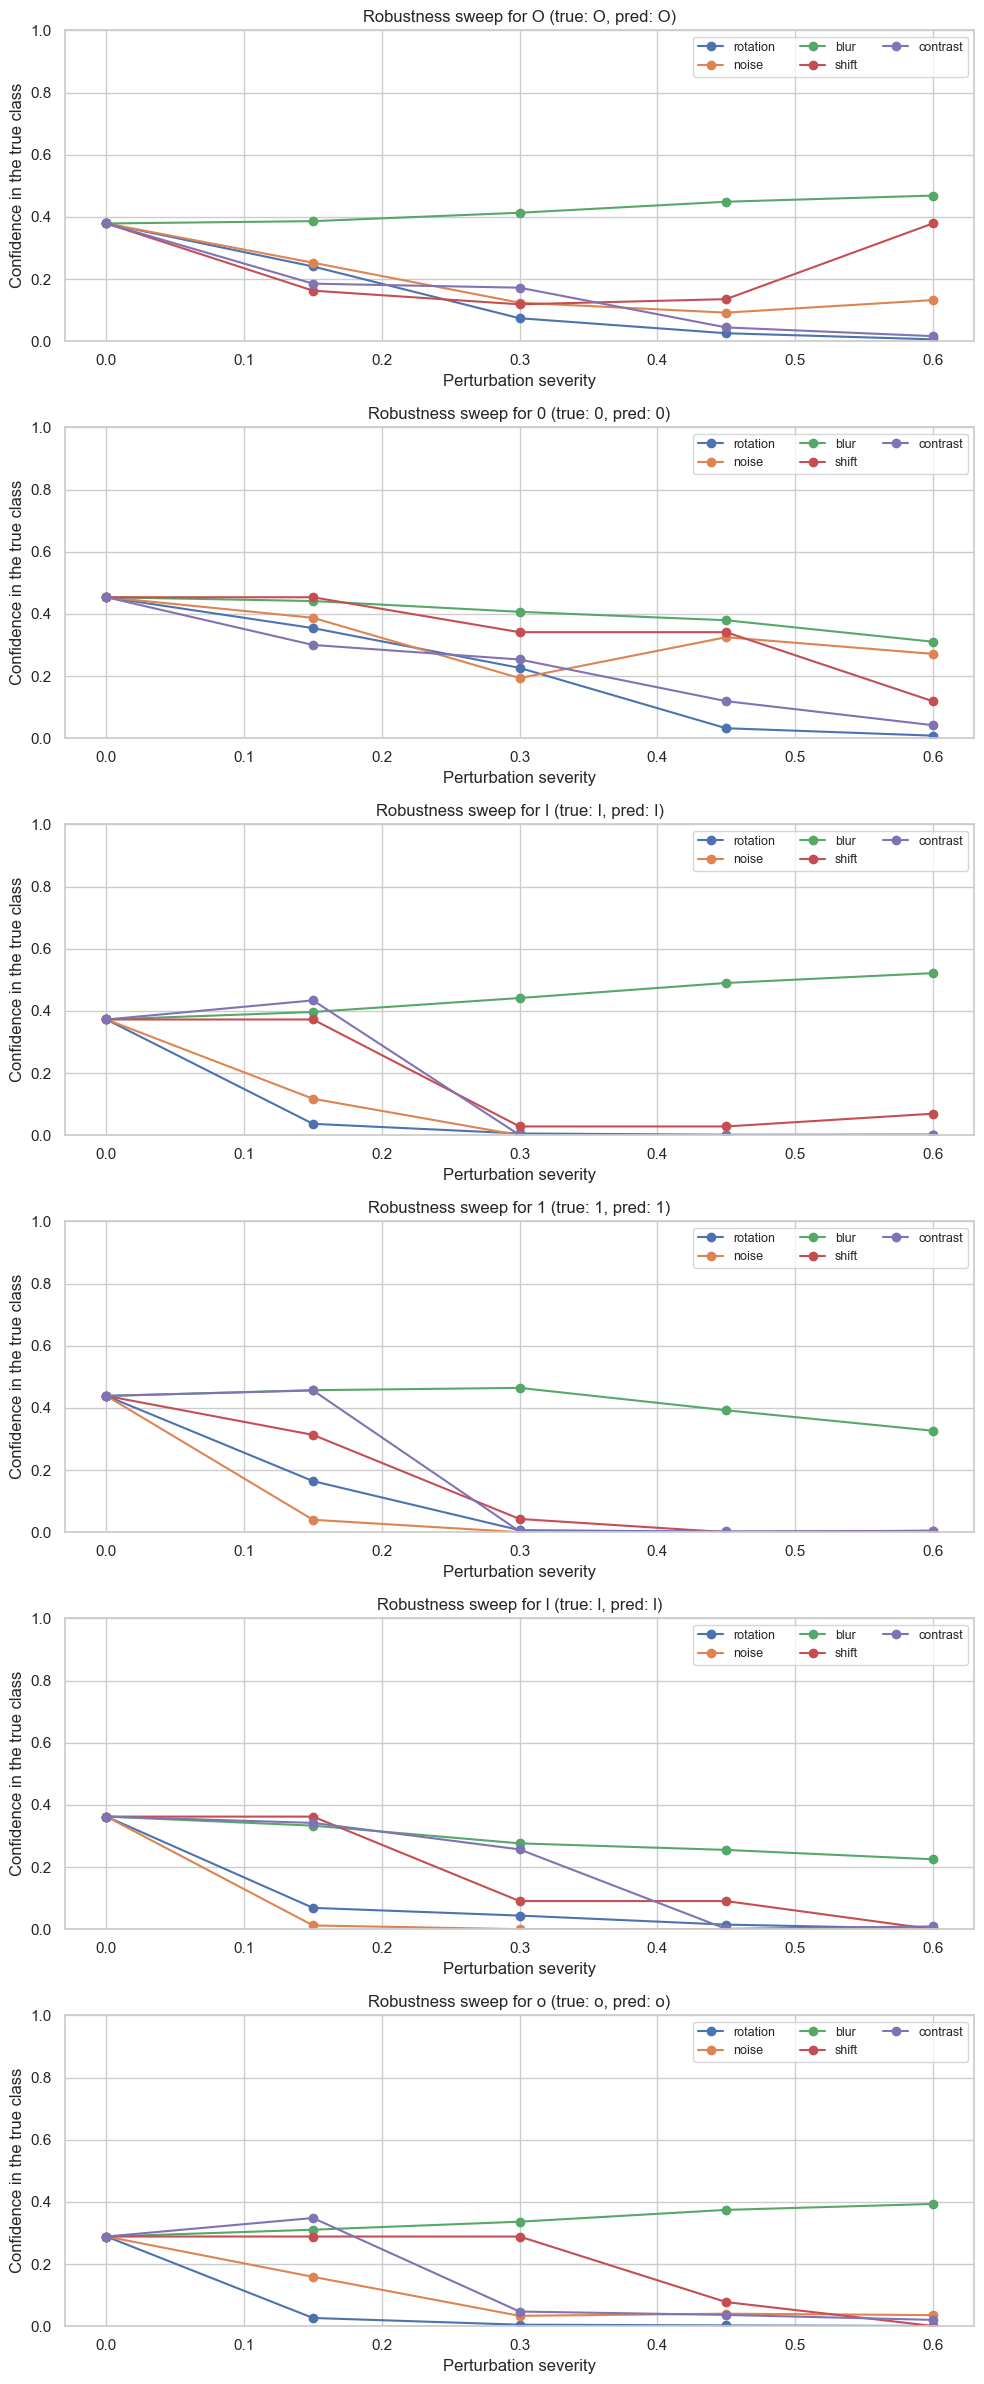

,character,true_label,baseline_prediction,baseline_confidence,worst_perturbation,worst_severity,worst_target_confidence,confidence_drop
0,O,O,O,0.378754,rotation,0.6,5.910781e-03,0.372843
1,0,0,0,0.453470,rotation,0.6,8.202869e-03,0.445267
2,I,I,I,0.372261,noise,0.3,2.020343e-08,0.372261
3,1,1,1,0.438511,noise,0.3,2.412680e-06,0.438509
4,l,l,l,0.362242,noise,0.3,7.778671e-06,0.362234
5,o,o,o,0.288499,shift,0.6,7.649428e-04,0.287734


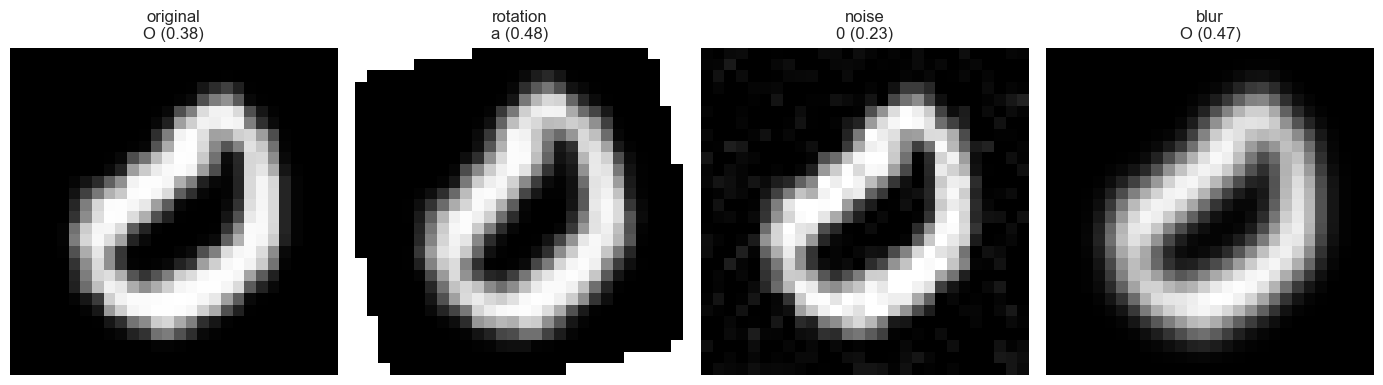

In [61]:
# Perturbation robustness on representative ambiguous characters.
perturb_kinds = ['rotation', 'noise', 'blur', 'shift', 'contrast']
severities = [0.0, 0.15, 0.30, 0.45, 0.60]
target_labels = ['O', '0', 'I', '1', 'l', 'o']

available_targets = {name: label_names.index(name) for name in target_labels if name in label_names}
representative_indices = {}
for name, class_idx in available_targets.items():
    correct_pool = np.where((y_test_subset == class_idx) & (cnn_test_pred == class_idx))[0]
    fallback_pool = np.where(y_test_subset == class_idx)[0]
    pool = correct_pool if len(correct_pool) > 0 else fallback_pool
    if len(pool) > 0:
        representative_indices[name] = int(pool[0])

sweep_summary_rows = []
if len(representative_indices) == 0:
    print('No target OCR classes were found in the sampled test subset.')
else:
    fig, axes = plt.subplots(len(representative_indices), 1, figsize=(10, 4 * len(representative_indices)), squeeze=False)
    axes = axes.reshape(-1)

    for ax, (true_name, idx) in zip(axes, representative_indices.items()):
        image = x_test_subset[idx]
        true_idx = int(y_test_subset[idx])
        base_pred_idx = int(cnn_test_pred[idx])
        base_conf = float(cnn_test_proba[idx, base_pred_idx])

        sweep = confidence_sweep(
            cnn,
            image,
            transform_kinds=perturb_kinds,
            severities=severities,
            predict_fn=lambda model, x: cnn_predict_from_gray(x),
            class_idx=true_idx,
        )

        for kind in perturb_kinds:
            kind_df = sweep[sweep['kind'] == kind].sort_values('severity')
            ax.plot(kind_df['severity'], kind_df['target_confidence'], marker='o', label=kind)

        min_row = sweep.loc[sweep['target_confidence'].idxmin()]
        sweep_summary_rows.append({
            'character': true_name,
            'true_label': label_names[true_idx],
            'baseline_prediction': label_names[base_pred_idx],
            'baseline_confidence': base_conf,
            'worst_perturbation': min_row['kind'],
            'worst_severity': float(min_row['severity']),
            'worst_target_confidence': float(min_row['target_confidence']),
            'confidence_drop': base_conf - float(min_row['target_confidence']),
        })

        ax.set_title(f'Robustness sweep for {true_name} (true: {label_names[true_idx]}, pred: {label_names[base_pred_idx]})')
        ax.set_xlabel('Perturbation severity')
        ax.set_ylabel('Confidence in the true class')
        ax.set_ylim(0, 1)
        ax.legend(ncol=3, fontsize=9)

    plt.tight_layout()
    plt.show()

    sweep_summary = pd.DataFrame(sweep_summary_rows)
    display(sweep_summary)

    # Visual sanity check: one example with a strong perturbation at the hardest severity.
    example_name, example_idx = next(iter(representative_indices.items()))
    example_image = x_test_subset[example_idx]
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    perturbations = [
        ('original', example_image),
        ('rotation', perturb_image(example_image, 'rotation', severity=0.60, seed=42)),
        ('noise', perturb_image(example_image, 'noise', severity=0.60, seed=42)),
        ('blur', perturb_image(example_image, 'blur', severity=0.60, seed=42)),
    ]
    for ax, (title, img) in zip(axes, perturbations):
        pred = cnn_predict_from_gray(img)
        pred_idx = int(np.argmax(pred))
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{title}\n{label_names[pred_idx]} ({float(pred[pred_idx]):.2f})')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


Selected example index: 0
True label: I
CNN prediction: l


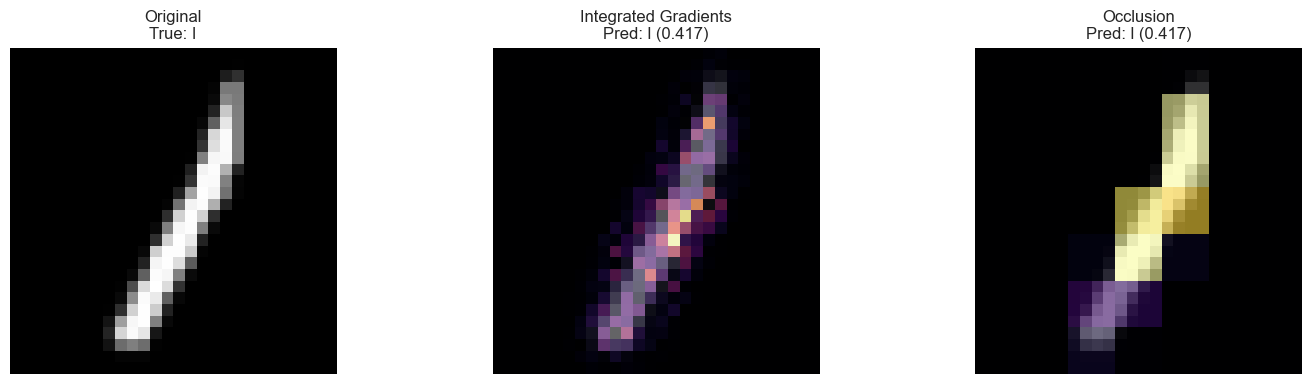

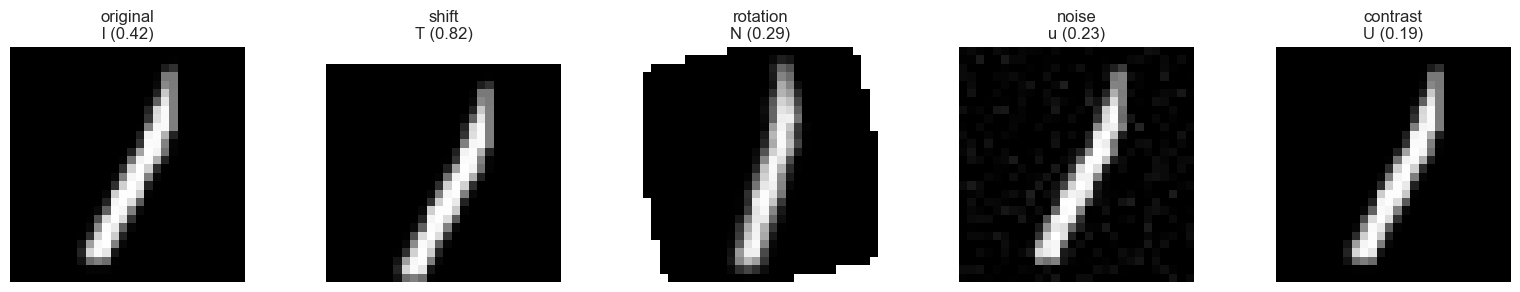

In [62]:
# Focused explainability on an ambiguous or misclassified character.
focus_names = ['O', '0', 'I', '1', 'l', 'o']
focus_indices = [label_names.index(name) for name in focus_names if name in label_names]
focus_pool = np.where(np.isin(y_test_subset, focus_indices))[0]
misclassified_pool = focus_pool[y_test_subset[focus_pool] != cnn_test_pred[focus_pool]]

if len(misclassified_pool) > 0:
    explanation_idx = int(misclassified_pool[0])
elif len(focus_pool) > 0:
    explanation_idx = int(focus_pool[0])
else:
    explanation_idx = 0

print('Selected example index:', explanation_idx)
print('True label:', label_names[int(y_test_subset[explanation_idx])])
print('CNN prediction:', label_names[int(cnn_test_pred[explanation_idx])])

plot_cnn_explanation(cnn, x_test_subset, y_test_subset, label_names, idx=explanation_idx)

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
visual_cases = [
    ('original', x_test_subset[explanation_idx]),
    ('shift', perturb_image(x_test_subset[explanation_idx], 'shift', severity=0.60, seed=1)),
    ('rotation', perturb_image(x_test_subset[explanation_idx], 'rotation', severity=0.60, seed=1)),
    ('noise', perturb_image(x_test_subset[explanation_idx], 'noise', severity=0.60, seed=1)),
    ('contrast', perturb_image(x_test_subset[explanation_idx], 'contrast', severity=0.60, seed=1)),
]

for ax, (title, img) in zip(axes, visual_cases):
    pred = cnn_predict_from_gray(img)
    pred_idx = int(np.argmax(pred))
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{title}\n{label_names[pred_idx]} ({float(pred[pred_idx]):.2f})')
    ax.axis('off')

plt.tight_layout()
plt.show()


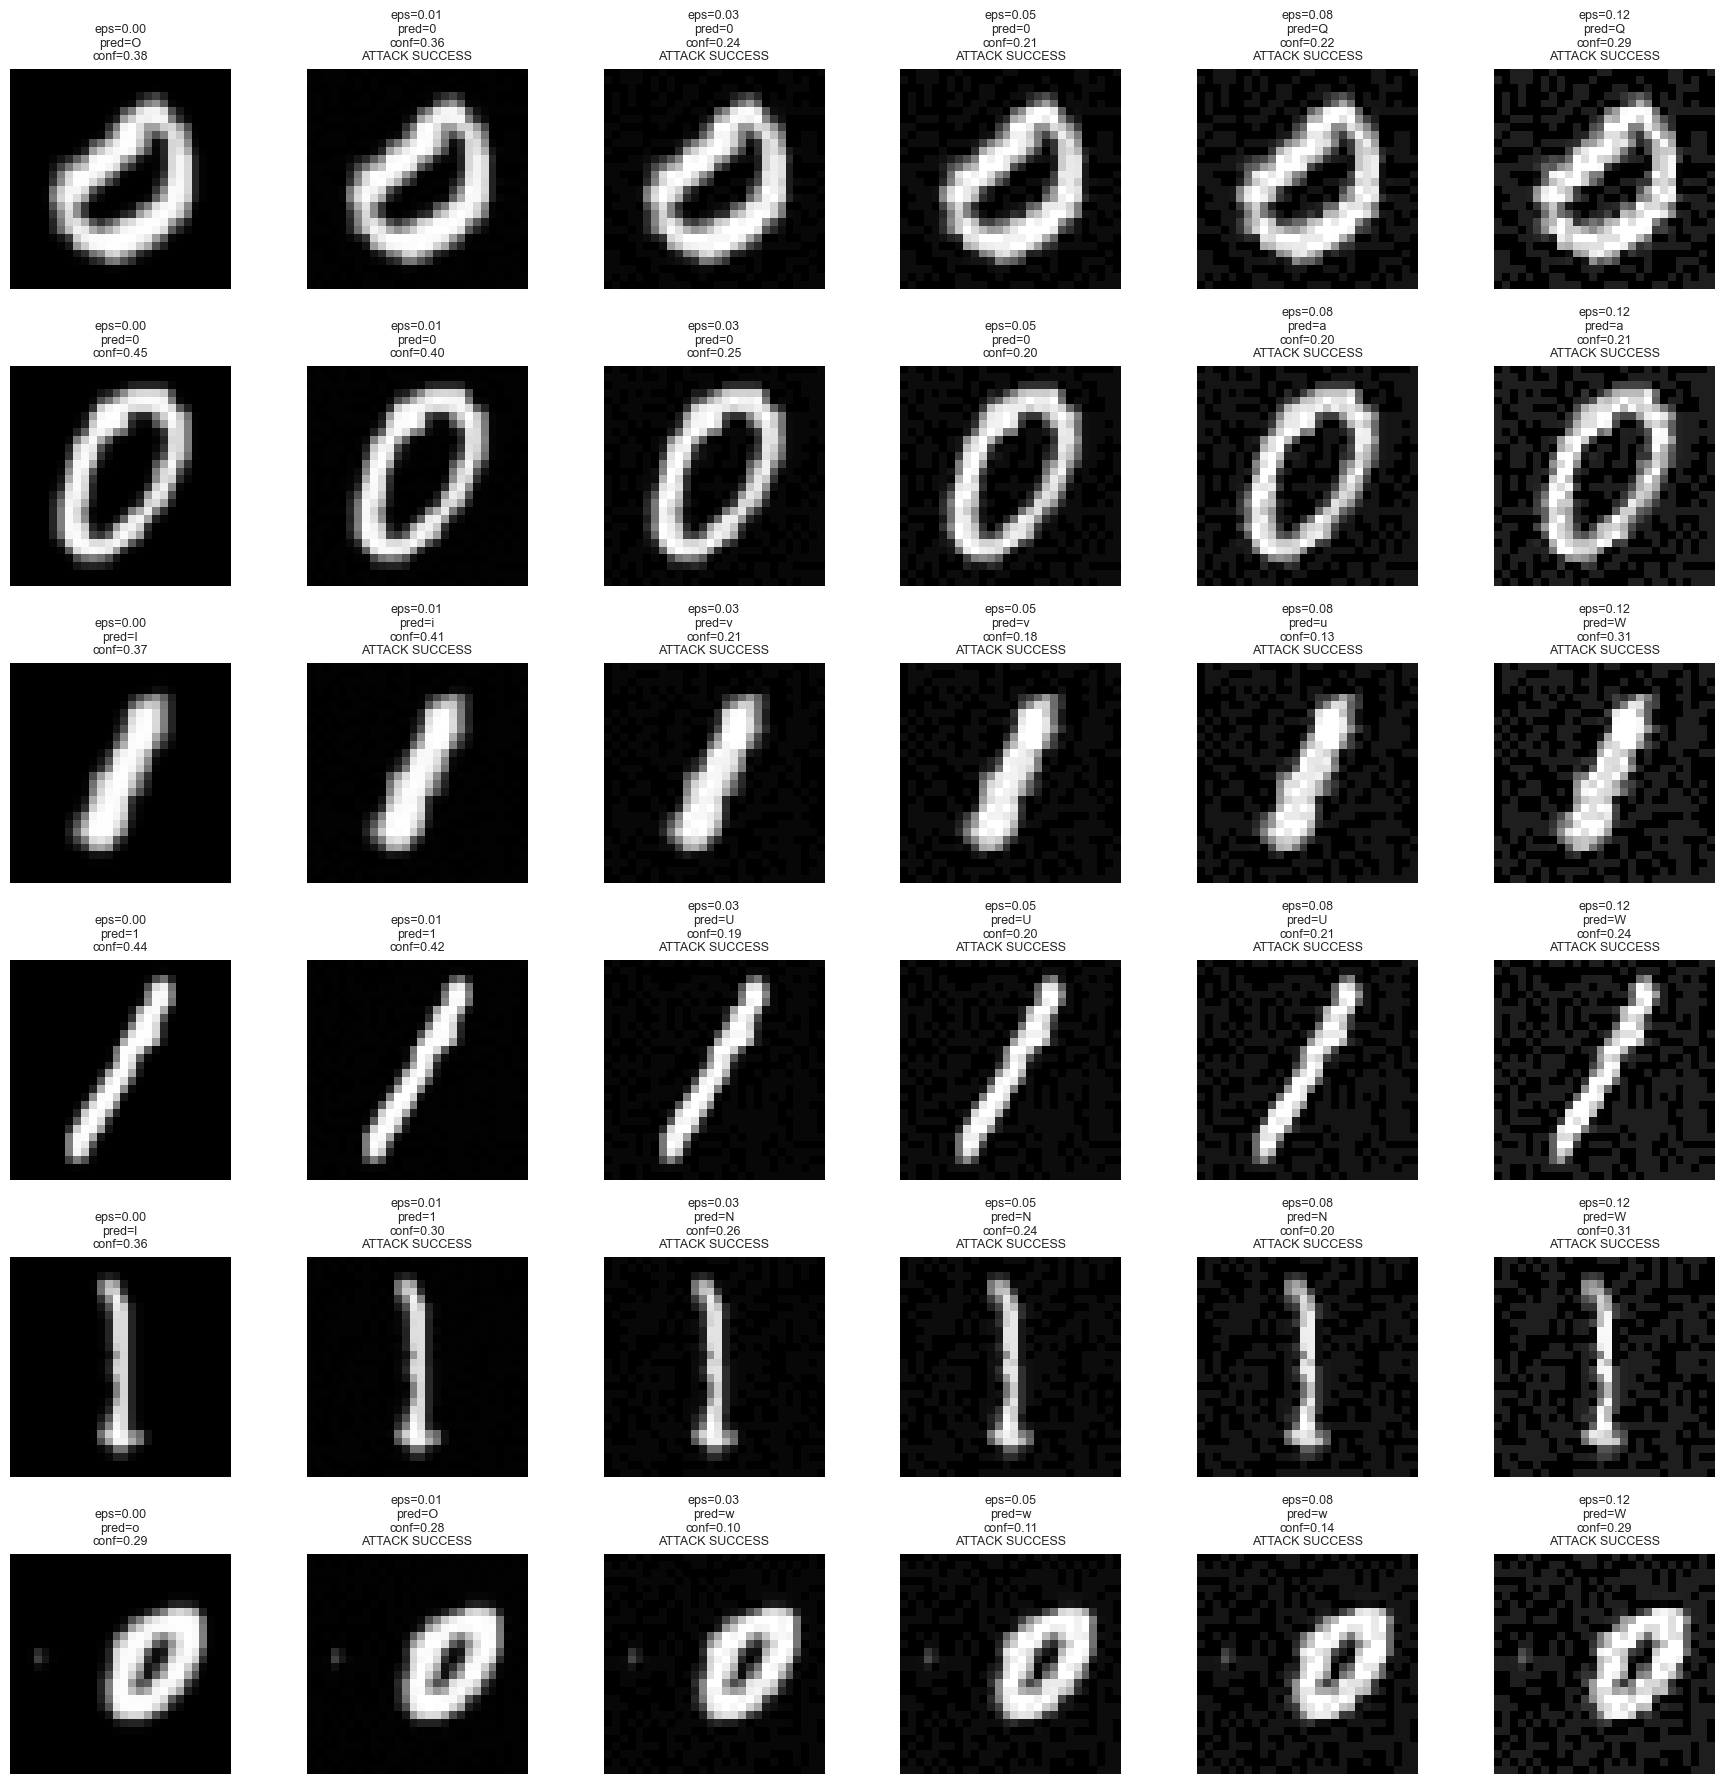

,character,epsilon,true_label,predicted_label,confidence,attack_success
0,O,0.00,O,O,0.378753,False
1,O,0.01,O,0,0.363648,True
2,O,0.03,O,0,0.243978,True
3,O,0.05,O,0,0.213589,True
4,O,0.08,O,Q,0.221045,True
5,O,0.12,O,Q,0.290560,True
6,0,0.00,0,0,0.453470,False
7,0,0.01,0,0,0.402673,False
8,0,0.03,0,0,0.254995,False
9,0,0.05,0,0,0.204149,False


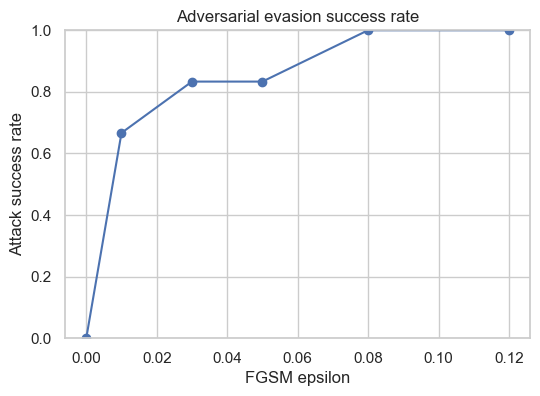

   epsilon  attack_success
0     0.00        0.000000
1     0.01        0.666667
2     0.03        0.833333
3     0.05        0.833333
4     0.08        1.000000
5     0.12        1.000000


In [63]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# ============================================================
# FGSM ADVERSARIAL EVASION ATTACK
# ============================================================

# Target ambiguous OCR characters
target_labels = ['O', '0', 'I', '1', 'l', 'o']

available_targets = {
    name: label_names.index(name)
    for name in target_labels
    if name in label_names
}

# ============================================================
# FGSM ATTACK FUNCTION
# ============================================================

def fgsm_attack(model, image, label, epsilon=0.05):
    """
    Generate adversarial example using FGSM.
    """

    image_2ch = prepare_cnn_input(image)
    image_tensor = tf.convert_to_tensor(image_2ch[None, ...], dtype=tf.float32)
    label_tensor = tf.convert_to_tensor([label], dtype=tf.int32)

    with tf.GradientTape() as tape:
        tape.watch(image_tensor)

        prediction = model(image_tensor, training=False)

        loss = tf.keras.losses.sparse_categorical_crossentropy(
            label_tensor,
            prediction
        )

    gradient = tape.gradient(loss, image_tensor)

    signed_grad = tf.sign(gradient)

    adversarial = image_tensor + epsilon * signed_grad

    adversarial = tf.clip_by_value(adversarial, 0.0, 1.0)

    return adversarial.numpy()[0, ..., 0]


# ============================================================
# SELECT REPRESENTATIVE SAMPLES
# ============================================================

representative_indices = {}

for name, class_idx in available_targets.items():

    correct_pool = np.where(
        (y_test_subset == class_idx) &
        (cnn_test_pred == class_idx)
    )[0]

    if len(correct_pool) > 0:
        representative_indices[name] = int(correct_pool[0])

# ============================================================
# ATTACK PARAMETERS
# ============================================================

epsilons = [0.0, 0.01, 0.03, 0.05, 0.08, 0.12]

attack_results = []

# ============================================================
# RUN EVASION ATTACKS
# ============================================================

fig, axes = plt.subplots(
    len(representative_indices),
    len(epsilons),
    figsize=(3 * len(epsilons), 3 * len(representative_indices))
)

if len(representative_indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, (true_name, idx) in enumerate(representative_indices.items()):

    original_image = x_test_subset[idx]
    true_label = int(y_test_subset[idx])

    original_pred = cnn.predict(
        prepare_cnn_input(original_image)[None, ...],
        verbose=0
    )

    original_pred_idx = int(np.argmax(original_pred))
    original_conf = float(original_pred[0, original_pred_idx])

    for col_idx, epsilon in enumerate(epsilons):

        adv_image = fgsm_attack(
            cnn,
            original_image,
            true_label,
            epsilon=epsilon
        )

        adv_pred = cnn.predict(
            prepare_cnn_input(adv_image)[None, ...],
            verbose=0
        )

        adv_pred_idx = int(np.argmax(adv_pred))
        adv_conf = float(adv_pred[0, adv_pred_idx])

        attack_success = adv_pred_idx != true_label

        attack_results.append({
            'character': true_name,
            'epsilon': epsilon,
            'true_label': label_names[true_label],
            'predicted_label': label_names[adv_pred_idx],
            'confidence': adv_conf,
            'attack_success': attack_success
        })

        ax = axes[row_idx, col_idx]

        ax.imshow(adv_image.squeeze(), cmap='gray')

        title = (
            f"eps={epsilon:.2f}\n"
            f"pred={label_names[adv_pred_idx]}\n"
            f"conf={adv_conf:.2f}"
        )

        if attack_success:
            title += "\nATTACK SUCCESS"

        ax.set_title(title, fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.show()

# ============================================================
# RESULTS TABLE
# ============================================================

attack_df = pd.DataFrame(attack_results)

display(attack_df)

# ============================================================
# ATTACK SUCCESS RATE
# ============================================================

success_rate = (
    attack_df.groupby('epsilon')['attack_success']
    .mean()
    .reset_index()
)

plt.figure(figsize=(6, 4))

plt.plot(
    success_rate['epsilon'],
    success_rate['attack_success'],
    marker='o'
)

plt.xlabel("FGSM epsilon")
plt.ylabel("Attack success rate")
plt.title("Adversarial evasion success rate")

plt.ylim(0, 1)

plt.grid(True)

plt.show()

print(success_rate)

## 2. Bias and Fairness

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def per_class_metrics_from_cm(cm, names):
    cm = np.asarray(cm, dtype=np.float64)
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    predicted = cm.sum(axis=0)
    precision = np.divide(tp, predicted, out=np.zeros_like(tp), where=predicted > 0)
    recall = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) > 0)

    return pd.DataFrame({
        'class': names,
        'support': support.astype(int),
        'predicted': predicted.astype(int),
        'precision': precision,
        'recall': recall,
        'f1': f1,
    })


train_support = np.bincount(y_train_subset, minlength=num_classes)
test_support = np.bincount(y_test_subset, minlength=num_classes)
imbalance_df = pd.DataFrame({
    'class': label_names,
    'train_support': train_support,
    'test_support': test_support,
    'train_share': train_support / train_support.sum(),
    'test_share': test_support / test_support.sum(),
})
imbalance_df['train_vs_test_ratio'] = np.divide(
    imbalance_df['train_support'],
    np.maximum(imbalance_df['test_support'], 1),
)

performance_df = per_class_metrics_from_cm(cm_cnn, label_names)
bias_fairness_df = imbalance_df.merge(performance_df, on='class', how='left')
bias_fairness_df['recall_gap_to_best'] = bias_fairness_df['recall'].max() - bias_fairness_df['recall']
bias_fairness_df['precision_gap_to_best'] = bias_fairness_df['precision'].max() - bias_fairness_df['precision']

display(bias_fairness_df.sort_values(['recall', 'precision']).reset_index(drop=True))

imbalance_ratio = float(train_support.max() / np.maximum(train_support.min(), 1))
recall_gap = float(performance_df['recall'].max() - performance_df['recall'].min())
precision_gap = float(performance_df['precision'].max() - performance_df['precision'].min())

summary_df = pd.DataFrame({
    'metric': ['train_imbalance_ratio', 'recall_gap', 'precision_gap'],
    'value': [imbalance_ratio, recall_gap, precision_gap],
})
display(summary_df)

worst_recall = performance_df.nsmallest(10, 'recall')[['class', 'support', 'precision', 'recall', 'f1']]
worst_precision = performance_df.nsmallest(10, 'precision')[['class', 'support', 'precision', 'recall', 'f1']]

print('Worst classes by recall:')
display(worst_recall)

print('Worst classes by precision:')
display(worst_precision)

focus_labels = ['O', '0', 'I', '1', 'l', 'o']
focus_indices = [label_names.index(name) for name in focus_labels if name in label_names]
if len(focus_indices) >= 2:
    focus_cm = cm_cnn[np.ix_(focus_indices, focus_indices)]
    focus_cm_df = pd.DataFrame(focus_cm, index=[label_names[i] for i in focus_indices], columns=[label_names[i] for i in focus_indices])
    display(focus_cm_df)

    focus_pairs = []
    for true_idx, true_name in zip(focus_indices, [label_names[i] for i in focus_indices]):
        for pred_idx, pred_name in zip(focus_indices, [label_names[i] for i in focus_indices]):
            if true_idx != pred_idx and cm_cnn[true_idx, pred_idx] > 0:
                focus_pairs.append({
                    'true_label': true_name,
                    'pred_label': pred_name,
                    'count': int(cm_cnn[true_idx, pred_idx]),
                })

    ambiguous_pairs_df = pd.DataFrame(focus_pairs).sort_values('count', ascending=False) if focus_pairs else pd.DataFrame(columns=['true_label', 'pred_label', 'count'])
    display(ambiguous_pairs_df.head(15))



print('Representation bias is measured here through class-support imbalance and per-class metric gaps.')
print('Fairness is interpreted as parity of performance across OCR symbols, not demographic fairness.')
print('Ambiguity bias is most visible in visually similar pairs such as O/0 and I/l/1.')


,class,train_support,test_support,train_share,test_share,train_vs_test_ratio,support,predicted,precision,recall,f1,recall_gap_to_best,precision_gap_to_best
0,o,473,80,0.003942,0.00400,5.912500,80,163,0.079755,0.162500,0.106996,0.837500,0.916312
1,M,1548,255,0.012900,0.01275,6.070588,255,115,0.808696,0.364706,0.502703,0.635294,0.187371
2,l,2634,436,0.021950,0.02180,6.041284,436,483,0.333333,0.369266,0.350381,0.630734,0.662734
3,s,464,75,0.003867,0.00375,6.186667,75,286,0.108392,0.413333,0.171745,0.586667,0.887675
4,C,1736,299,0.014467,0.01495,5.806020,299,154,0.844156,0.434783,0.573951,0.565217,0.151911
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,L,873,139,0.007275,0.00695,6.280576,139,159,0.855346,0.978417,0.912752,0.021583,0.140721
58,d,1750,289,0.014583,0.01445,6.055363,289,300,0.950000,0.986159,0.967742,0.013841,0.046067
59,N,1416,232,0.011800,0.01160,6.103448,232,247,0.927126,0.987069,0.956159,0.012931,0.068941
60,3,6042,1026,0.050350,0.05130,5.888889,1026,1017,0.996067,0.987329,0.991679,0.012671,0.000000


,metric,value
0,train_imbalance_ratio,20.239264
1,recall_gap,0.837500
2,precision_gap,0.916312


Worst classes by recall:


,class,support,precision,recall,f1
50,o,80,0.079755,0.162500,0.106996
22,M,255,0.808696,0.364706,0.502703
47,l,436,0.333333,0.369266,0.350381
54,s,75,0.108392,0.413333,0.171745
12,C,299,0.844156,0.434783,0.573951
18,I,352,0.451253,0.460227,0.455696
46,k,80,0.722222,0.487500,0.582090
51,p,63,0.402597,0.492063,0.442857
24,O,715,0.620690,0.503497,0.555985
28,S,603,0.827027,0.507463,0.628983


Worst classes by precision:


,class,support,precision,recall,f1
50,o,80,0.079755,0.162500,0.106996
54,s,75,0.108392,0.413333,0.171745
38,c,74,0.246512,0.716216,0.366782
44,i,73,0.284722,0.561644,0.377880
48,m,80,0.293103,0.850000,0.435897
41,f,69,0.314917,0.826087,0.456000
47,l,436,0.333333,0.369266,0.350381
56,u,83,0.335526,0.614458,0.434043
61,z,78,0.346154,0.576923,0.432692
52,q,87,0.368000,0.528736,0.433962


,O,0,I,1,l,o
O,360,246,0,0,0,72
0,183,657,0,0,0,77
I,0,0,162,89,54,0
1,0,0,99,662,264,0
l,0,0,81,158,161,0
o,37,25,0,0,0,13


,true_label,pred_label,count
7,1,l,264
0,O,0,246
2,0,O,183
9,l,1,158
6,1,I,99
4,I,1,89
8,l,I,81
3,0,o,77
1,O,o,72
5,I,l,54


Representation bias is measured here through class-support imbalance and per-class metric gaps.
Fairness is interpreted as parity of performance across OCR symbols, not demographic fairness.
Ambiguity bias is most visible in visually similar pairs such as O/0 and I/l/1.


### Bias and Fairness Report

The OCR task shows two main sources of bias. First, the raw character distribution is not perfectly balanced, so some symbols appear more often than others. This creates representation bias because a model trained on the raw data can become more reliable on common classes and weaker on rare ones.

In this notebook, that issue is reduced by training and evaluating on a balanced subset. The remaining fairness question is therefore not demographic fairness, but performance parity across character classes. The most useful fairness indicators are the gaps in per-class precision and recall, together with the confusion matrix.

A second and more important issue is ambiguity bias. Some OCR symbols are naturally hard to separate, especially `O` vs `0` and `I` vs `l` or `1`. These classes tend to generate the most confusions and usually have lower recall than clearer characters. In practice, this means the model is not equally reliable across all symbols, even when the dataset is balanced.

Overall, the main fairness risk in this project is unequal performance across visually similar characters rather than bias against a sensitive demographic group. The analysis below supports that conclusion by showing class-level support, recall, precision, and the strongest ambiguous confusions.

## 3. Explainable AI (xAI)

This section focuses on **why** the OCR model predicts a character, not just the final label. We first choose a character class to compare the baseline model and the CNN on the same kind of sample. Then we visualize the CNN with Integrated Gradients, occlusion sensitivity, and activation maximization so we can see whether it relies on meaningful strokes or on noisy pixels.

Selected indices for classes ['V']: [12, 396]
Selected comparison class names: ['V']
Selected comparison indices: [12, 396]


,index,true_label,cnn_prediction,cnn_correct,cnn_confidence,baseline_prediction,baseline_correct,baseline_confidence
0,12,V,V,True,0.567717,v,False,0.556314
1,396,V,u,False,0.368858,N,False,0.449606


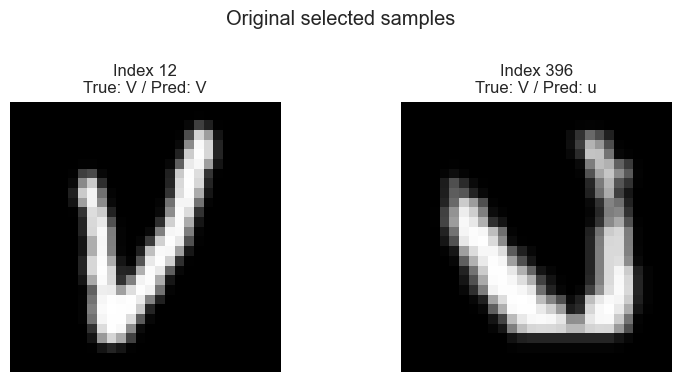

Baseline vs CNN attention comparison for: ['V']


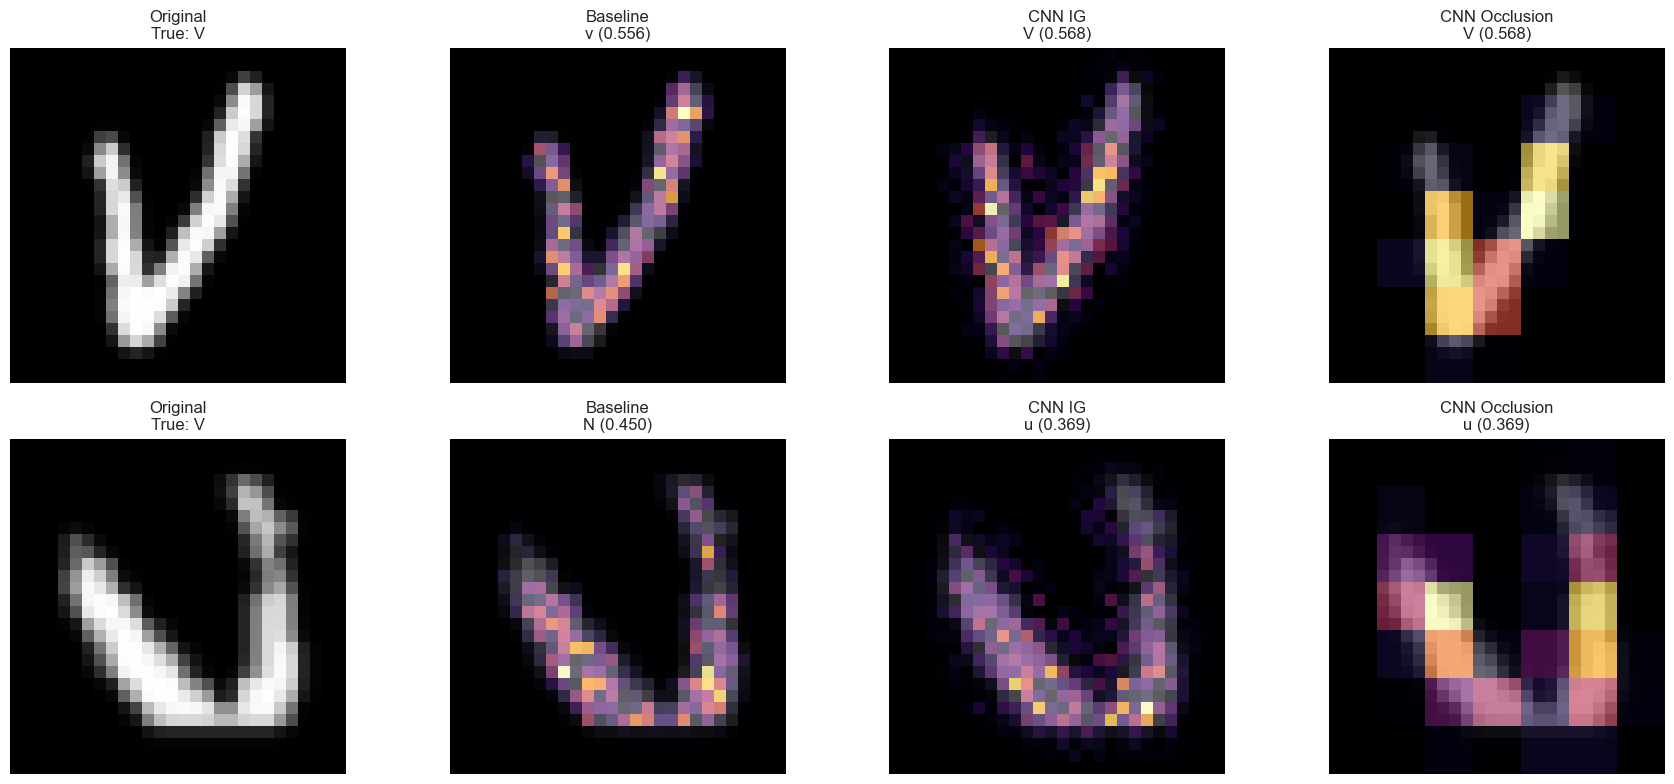

Explainability triptych for sample 12 (V)


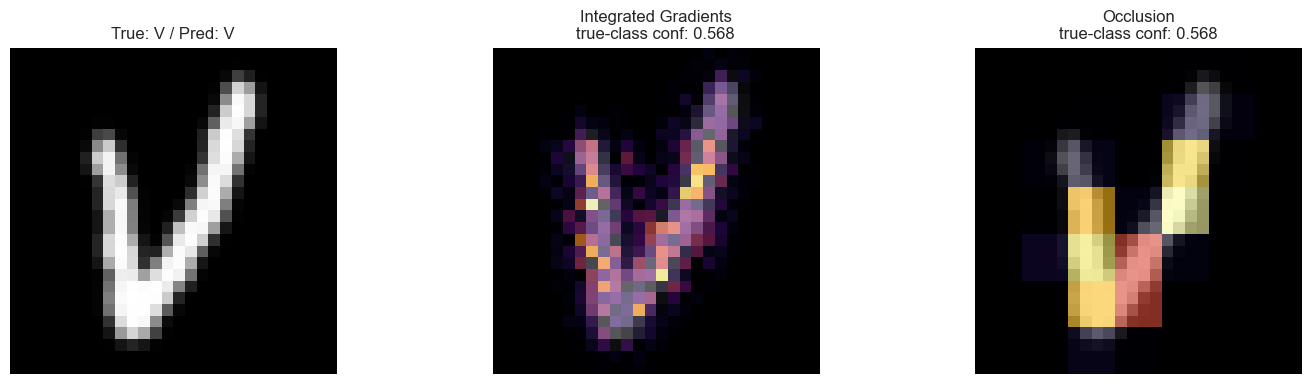

Explainability triptych for sample 396 (V)


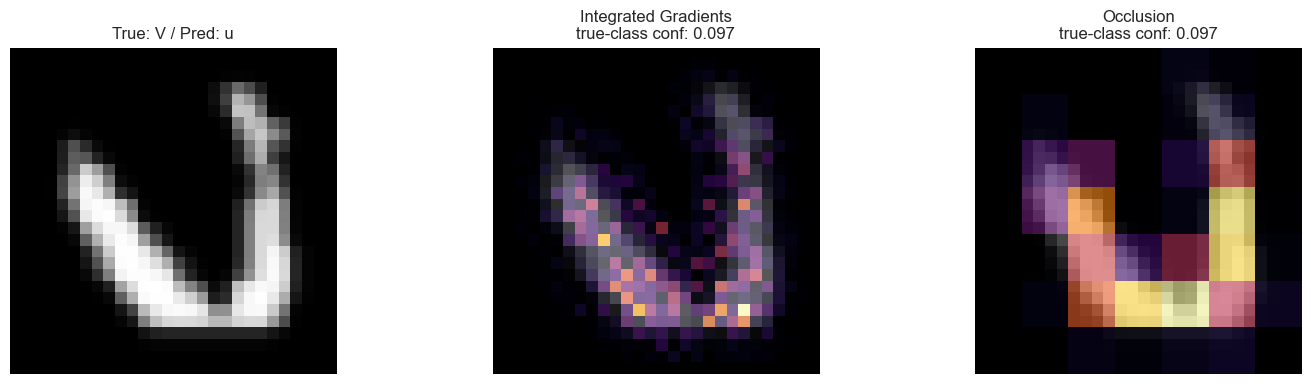

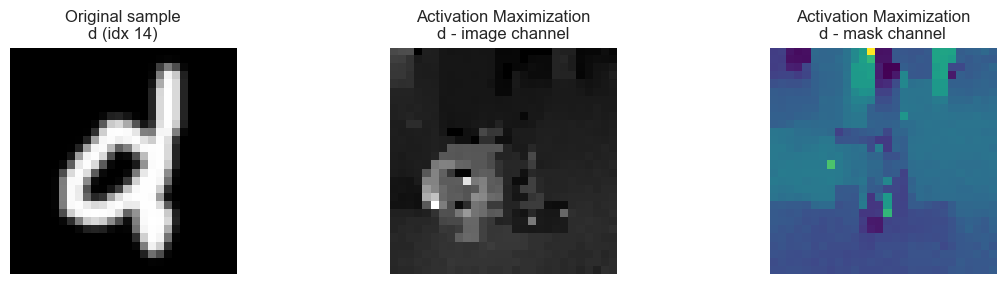

,class,original_index,mean,min,max
0,d,14,0.110835,0.0,0.521269


In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from IPython.display import display

def activation_maximization(model, class_idx, steps=180, learning_rate=0.05, tv_weight=1e-3, l2_weight=1e-3, seed=42, init='zeros'):
    """Build a class prototype by maximizing the CNN score with gradient ascent.

    init can be 'noise' or 'zeros'.
    """
    tf.random.set_seed(seed)
    # Start from either a blank canvas or random noise.
    if init == 'zeros':
        image = tf.Variable(tf.zeros((1, 28, 28, 2), dtype=tf.float32))
    elif init == 'noise':
        image = tf.Variable(tf.random.uniform((1, 28, 28, 2), 0.0, 1.0, seed=seed))
    else:
        raise ValueError("init must be 'noise' or 'zeros'")
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    # Ascend the gradient so the chosen class score increases over time.
    for _ in range(steps):
        with tf.GradientTape() as tape:
            preds = model(image, training=False)
            class_score = tf.reduce_mean(preds[:, class_idx])
            tv_penalty = tf.reduce_mean(tf.image.total_variation(image))
            l2_penalty = tf.reduce_mean(tf.square(image))
            loss = -class_score + tv_weight * tv_penalty + l2_weight * l2_penalty

        grads = tape.gradient(loss, image)
        optimizer.apply_gradients([(grads, image)])
        image.assign(tf.clip_by_value(image, 0.0, 1.0))

    return image.numpy()[0]


def plot_explanation_triptych(model, idx, names):
    # Show the raw image, Integrated Gradients, and occlusion for the same sample.
    image = x_test_subset[idx]
    true_idx = int(y_test_subset[idx])
    pred_idx = int(cnn_test_pred[idx])
    ig_map, _, ig_conf = integrated_gradients_map(model, image, class_idx=true_idx)
    occ_map, _, occ_conf = occlusion_map(model, image, class_idx=true_idx)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(f'True: {names[true_idx]} / Pred: {names[pred_idx]}')
    axes[0].axis('off')

    axes[1].imshow(image, cmap='gray')
    axes[1].imshow(ig_map, cmap='inferno', alpha=0.6)
    axes[1].set_title(f'Integrated Gradients\ntrue-class conf: {ig_conf:.3f}')
    axes[1].axis('off')

    axes[2].imshow(image, cmap='gray')
    axes[2].imshow(occ_map, cmap='inferno', alpha=0.6)
    axes[2].set_title(f'Occlusion\ntrue-class conf: {occ_conf:.3f}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


# Edit this list to choose which class(es) to compare in the baseline-vs-CNN explainability plots.
# Example: ['R'] or ['O', '0'].
COMPARE_CLASS_NAMES = ['V']
DEFAULT_FOCUS_NAMES = ['O', '0', 'I', '1', 'l', 'o']

def pick_examples_for_classes(class_names, min_examples=2):
    # Try to return a mix of correct and incorrect examples for the chosen class.
    resolved_names = [name for name in class_names if name in label_names]
    if len(resolved_names) == 0:
        resolved_names = [name for name in DEFAULT_FOCUS_NAMES if name in label_names]

    selected = []
    for class_name in resolved_names:
        class_idx = label_names.index(class_name)
        class_pool = np.where(y_test_subset == class_idx)[0]
        correct_pool = class_pool[y_test_subset[class_pool] == cnn_test_pred[class_pool]]
        incorrect_pool = class_pool[y_test_subset[class_pool] != cnn_test_pred[class_pool]]

        if len(correct_pool) > 0:
            selected.append(int(correct_pool[0]))
        if len(selected) >= min_examples:
            break
        if len(incorrect_pool) > 0:
            selected.append(int(incorrect_pool[0]))
        if len(selected) >= min_examples:
            break

        remaining = [int(i) for i in class_pool if int(i) not in selected]
        for idx in remaining:
            selected.append(idx)
            if len(selected) >= min_examples:
                break
        if len(selected) >= min_examples:
            break

    if len(selected) < min_examples:
        fallback_pool = np.arange(len(y_test_subset))
        remaining = [int(i) for i in fallback_pool if int(i) not in selected]
        selected.extend(remaining[: min_examples - len(selected)])
    print(f"Selected indices for classes {resolved_names}: {selected[:min_examples]}")

    return selected[:min_examples], resolved_names

selected_indices, selected_class_names = pick_examples_for_classes(COMPARE_CLASS_NAMES, min_examples=2)
print('Selected comparison class names:', selected_class_names)
print('Selected comparison indices:', selected_indices)

example_summary = []
for idx in selected_indices:
    true_idx = int(y_test_subset[idx])
    pred_idx = int(cnn_test_pred[idx])
    example_summary.append({
        'index': idx,
        'true_label': label_names[true_idx],
        'cnn_prediction': label_names[pred_idx],
        'cnn_correct': bool(true_idx == pred_idx),
        'cnn_confidence': float(cnn_test_proba[idx, pred_idx]),
        'baseline_prediction': label_names[int(test_baseline_pred[idx])],
        'baseline_correct': bool(int(y_test_subset[idx]) == int(test_baseline_pred[idx])),
        'baseline_confidence': float(baseline.predict_proba(x_test_flat[idx].reshape(1, -1))[0][int(test_baseline_pred[idx])]),
    })

selected_examples_df = pd.DataFrame(example_summary)
display(selected_examples_df)

# First show the original OCR characters so the reader knows what we are explaining.
if len(selected_indices) > 0:
    fig, axes = plt.subplots(1, len(selected_indices), figsize=(4 * len(selected_indices), 4))
    axes = np.atleast_1d(axes)
    for ax, idx in zip(axes, selected_indices):
        image = x_test_subset[idx]
        true_name = label_names[int(y_test_subset[idx])]
        pred_name = label_names[int(cnn_test_pred[idx])]
        ax.imshow(image, cmap='gray')
        ax.set_title(f'Index {idx}\nTrue: {true_name} / Pred: {pred_name}')
        ax.axis('off')
    plt.suptitle('Original selected samples')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Then compare baseline and CNN explanations on the same selected samples.
if len(selected_indices) >= 1:
    print(f'Baseline vs CNN attention comparison for: {selected_class_names}')
    plot_comparison_gallery(baseline, cnn, x_test_subset, y_test_subset, label_names, selected_indices[:len(selected_indices)])

# Finally show the CNN explanation overlays for each selected sample.
for idx in selected_indices[:2]:
    print(f'Explainability triptych for sample {idx} ({label_names[int(y_test_subset[idx])]})')
    plot_explanation_triptych(cnn, idx, label_names)

# Activation maximization is shown on a few reference classes.
activation_targets = [name for name in ["d"] if name in label_names][:3]
if len(activation_targets) == 0:
    activation_targets = label_names[:3]

def find_original_index_for_class(class_idx):
    # Grab one real sample from the test set for the same class.
    pool = np.where(y_test_subset == class_idx)[0]
    if len(pool) > 0:
        return int(pool[0])
    return None

fig, axes = plt.subplots(len(activation_targets), 3, figsize=(12, 3 * len(activation_targets)))
if len(activation_targets) == 1:
    axes = np.expand_dims(axes, axis=0)

activation_rows = []
for row, class_name in enumerate(activation_targets):
    # Compare the learned prototype with a real example from the same class.
    class_idx = label_names.index(class_name)
    original_idx = find_original_index_for_class(class_idx)
    am_image = activation_maximization(cnn, class_idx)
    activation_rows.append({
        'class': class_name,
        'original_index': original_idx,
        'mean': float(am_image.mean()),
        'min': float(am_image.min()),
        'max': float(am_image.max()),
    })

    if original_idx is not None:
        original_image = x_test_subset[original_idx]
        axes[row, 0].imshow(original_image, cmap='gray')
        axes[row, 0].set_title(f'Original sample\n{class_name} (idx {original_idx})')
    else:
        axes[row, 0].text(0.5, 0.5, 'No sample found', ha='center', va='center')
        axes[row, 0].set_title(f'Original sample\n{class_name}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(am_image[..., 0], cmap='gray')
    axes[row, 1].set_title(f'Activation Maximization\n{class_name} - image channel')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(am_image[..., 1], cmap='viridis')
    axes[row, 2].set_title(f'Activation Maximization\n{class_name} - mask channel')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

activation_summary_df = pd.DataFrame(activation_rows)
display(activation_summary_df)


### Explainability Report

Explainability is one of the strongest OCR sections because the inputs are tiny 28x28 characters, so the model's decision can be inspected directly at pixel level.

**What we compare**: the notebook lets us choose the target class with `COMPARE_CLASS_NAMES`, so we can study a specific character like `R` instead of only ambiguous symbols.

**Integrated Gradients**: this highlights which strokes support the CNN prediction. We use it because it gives a clear attribution map and usually focuses on the character shape rather than the background.

**Occlusion sensitivity**: this removes small patches and measures the confidence drop. We use it because it answers a simple question: which parts of the character are essential for the prediction?

**Baseline vs CNN attention**: the linear baseline usually looks noisy and scattered, while the CNN tends to focus on coherent stroke regions. This supports the idea that the CNN has learned spatial structure.

**Successful vs failed explanations**: correct predictions usually show consistent evidence on the main strokes, while failed cases often light up ambiguous regions such as `O` vs `0` or `I` vs `l` / `1`. This helps explain the model's errors instead of only reporting them.

**Activation Maximization**: we start from a zero image or noise and perform gradient ascent to maximize one class score. We show the optimized prototype next to a real sample from the same class so the reader can compare the learned template with an actual OCR character.

Overall, this section shows that the CNN is not only more accurate than the baseline, but also more interpretable. Its explanations are localized on meaningful character strokes, which makes the model easier to justify in the report.